# RQA core validation and parameter sensitivity

This notebook validates `src/rqa/rqa.py` and evaluates `l_min` and `v_min` on Session 1. Results remain in memory; no tables, figures, or intermediate arrays are saved.

Cutoffs are assessed from metric stability, line support, and robustness across representation and window size. Awake–Drowsy separation is descriptive only.

## Cell 1 — Imports and configuration

Import the project APIs and define the fixed scientific settings.


In [1]:
import gc
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start):
    """Find the repository root from a notebook working directory."""
    candidates = (start, *start.parents)
    for candidate in candidates:
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data, load_segmented_session
from rqa import rqa as rqa_core


SESSION = "sample_1"
WINDOW_SIZES = (60, 120, 180)
M = 8
TAU_SECONDS = {"Processed": 0.16, "Raw": 0.20}
RADIUS_FRACTION = 0.10
L_MIN_BASE = 2
V_MIN_BASE = 2

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})

print("RQA test configuration")
print(f"m = {M}")
print(f"radius fraction = {RADIUS_FRACTION:.2f}")
print(f"Session = {SESSION.removeprefix('sample_')}")


RQA test configuration
m = 8
radius fraction = 0.10
Session = 1


## Cell 2 — Load Session 1 metadata

Inspect all SQI-approved segmented windows. Processed PPG uses its stationarity filter; Raw PPG uses every SQI window without stationarity filtering.


In [2]:
all_batches, _ = load_segmented_session(
    session=SESSION,
    window_sizes=WINDOW_SIZES,
    representation="both",
    stationarity_only=False,
)

metadata_rows = []
for window_size, batch in all_batches.items():
    for representation in ("Processed", "Raw"):
        pass_key = f"stationarity_pass_{representation.lower()}"
        for index, window_id in enumerate(batch["window_id"]):
            label = int(batch["label"][index])
            stationarity_pass = bool(batch[pass_key][index])
            stationarity_filter = (
                "processed"
                if representation == "Processed"
                else "disabled"
            )
            metadata_rows.append(
                {
                    "representation": representation,
                    "state": "Awake" if label == 0 else "Drowsy",
                    "window_size": window_size,
                    "window_id": int(window_id),
                    "fs": float(batch["fs"]),
                    "stationarity_filter": stationarity_filter,
                    "stationarity_pass": stationarity_pass,
                    "eligible": (
                        stationarity_pass
                        if representation == "Processed"
                        else True
                    ),
                }
            )

window_metadata = pd.DataFrame(metadata_rows)
coverage_table = (
    window_metadata.groupby(
        [
            "representation",
            "state",
            "window_size",
            "stationarity_filter",
        ],
        observed=True,
    )
    .agg(
        n_windows=("eligible", "sum"),
        n_sqi_windows=("window_id", "size"),
        n_stationary=("stationarity_pass", "sum"),
        fs=("fs", "first"),
    )
    .reset_index()
    .sort_values(["representation", "state", "window_size"])
)

processed_awake, processed_drowsy = get_data(
    session=SESSION,
    window_sizes=WINDOW_SIZES,
    stationarity="processed",
)
raw_batches, _ = load_segmented_session(
    session=SESSION,
    window_sizes=WINDOW_SIZES,
    representation="raw",
    stationarity_only=False,
)

raw_state_data = {"Awake": {}, "Drowsy": {}}
for window_size, batch in raw_batches.items():
    for label, state in ((0, "Awake"), (1, "Drowsy")):
        selected = batch["label"] == label
        raw_state_data[state][window_size] = {
            "raw": batch["signal"][selected],
            "window_id": batch["window_id"][selected],
            "fs": batch["fs"],
        }

session_data = {
    "Processed": {
        "Awake": processed_awake,
        "Drowsy": processed_drowsy,
    },
    "Raw": raw_state_data,
}

display(coverage_table)


,representation,state,window_size,stationarity_filter,n_windows,n_sqi_windows,n_stationary,fs
0,Processed,Awake,60,processed,24,24,24,50.0
1,Processed,Awake,120,processed,11,11,11,50.0
2,Processed,Awake,180,processed,6,6,6,50.0
3,Processed,Drowsy,60,processed,7,10,7,50.0
4,Processed,Drowsy,120,processed,1,3,1,50.0
5,Processed,Drowsy,180,processed,1,1,1,50.0
6,Raw,Awake,60,disabled,24,24,14,50.0
7,Raw,Awake,120,disabled,11,11,8,50.0
8,Raw,Awake,180,disabled,6,6,5,50.0
9,Raw,Drowsy,60,disabled,10,10,3,50.0


## Cell 3 — Input quality control

Verify finite values, nominal lengths, sampling rates, delays, Theiler windows, and embedding support for every selected window.


In [3]:
def iter_selected_windows():
    """Yield every analysis-ready Session 1 window."""
    for representation, state_data in session_data.items():
        signal_key = representation.lower()
        for state, batches in state_data.items():
            for window_size, batch in batches.items():
                signals = batch[signal_key]
                for index, signal in enumerate(signals):
                    yield {
                        "representation": representation,
                        "state": state,
                        "window_size": int(window_size),
                        "window_id": int(batch["window_id"][index]),
                        "fs": float(batch["fs"]),
                        "signal": signal,
                    }


qc_rows = []
for item in iter_selected_windows():
    signal = np.asarray(item["signal"], dtype=float)
    fs = item["fs"]
    tau = int(round(TAU_SECONDS[item["representation"]] * fs))
    theiler = (M - 1) * tau
    expected_samples = int(round(item["window_size"] * fs))
    qc_rows.append(
        {
            "repr": item["representation"],
            "state": item["state"],
            "size": item["window_size"],
            "window_id": item["window_id"],
            "n": signal.size,
            "fs": fs,
            "tau": tau,
            "Theiler": theiler,
            "finite": bool(np.all(np.isfinite(signal))),
            "length_valid": signal.size == expected_samples,
            "fs_valid": bool(np.isfinite(fs) and fs > 0.0),
            "embedding_valid": signal.size > theiler,
        }
    )

qc_table = pd.DataFrame(qc_rows)
qc_columns = [
    "finite",
    "length_valid",
    "fs_valid",
    "embedding_valid",
]
failed_qc = qc_table.loc[~qc_table[qc_columns].all(axis=1)]

display(qc_table)
if failed_qc.empty:
    print("All selected windows passed input QC.")
else:
    display(failed_qc)
    raise AssertionError("Some selected windows failed input QC.")


,repr,state,size,window_id,n,fs,tau,Theiler,finite,length_valid,fs_valid,embedding_valid
0,Processed,Awake,60,1,3000,50.0,8,56,True,True,True,True
1,Processed,Awake,60,2,3000,50.0,8,56,True,True,True,True
2,Processed,Awake,60,3,3000,50.0,8,56,True,True,True,True
3,Processed,Awake,60,4,3000,50.0,8,56,True,True,True,True
4,Processed,Awake,60,5,3000,50.0,8,56,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
100,Raw,Drowsy,60,34,3000,50.0,10,70,True,True,True,True
101,Raw,Drowsy,120,9,6000,50.0,10,70,True,True,True,True
102,Raw,Drowsy,120,11,6000,50.0,10,70,True,True,True,True
103,Raw,Drowsy,120,14,6000,50.0,10,70,True,True,True,True


All selected windows passed input QC.


## Cell 4 — Synthetic periodic signal

Exercise the complete wrapper on a deterministic periodic signal and verify all output bounds.


In [4]:
def assert_rqa_bounds(result, l_min, v_min):
    """Validate generic RQA bounds without assuming signal dynamics."""
    values = np.asarray(
        [
            result.det,
            result.l_mean,
            result.entr,
            result.l_max,
            result.lam,
            result.tt,
            result.v_max,
            result.recurrence_rate,
            result.epsilon,
        ],
        dtype=float,
    )
    assert np.all(np.isfinite(values))
    assert 0.0 <= result.det <= 1.0
    assert 0.0 <= result.lam <= 1.0
    assert 0.0 <= result.recurrence_rate <= 1.0
    assert result.entr >= 0.0
    assert result.epsilon > 0.0
    if result.n_diagonal_lines:
        assert result.l_mean >= l_min
        assert result.l_max >= result.l_mean
    if result.n_vertical_lines:
        assert result.tt >= v_min
        assert result.v_max >= result.tt


synthetic_fs = 50.0
synthetic_time = np.arange(20 * int(synthetic_fs)) / synthetic_fs
periodic_signal = np.sin(2.0 * np.pi * 1.2 * synthetic_time)
periodic_result = rqa_core.run_rqa(
    periodic_signal,
    m=M,
    tau=int(round(TAU_SECONDS["Processed"] * synthetic_fs)),
    l_min=L_MIN_BASE,
    v_min=V_MIN_BASE,
    radius_fraction=RADIUS_FRACTION,
)

assert_rqa_bounds(periodic_result, L_MIN_BASE, V_MIN_BASE)
print(periodic_result)
print("Synthetic periodic test: PASS")


RQAResult(det=0.9994725738396625, l_mean=75.8, entr=1.4538146228881261, l_max=861, lam=0.9990770042194093, tt=2.845287269996245, v_max=3, recurrence_rate=0.06739998171790731, epsilon=0.40592258158507355, theiler=56, n_diagonal_lines=350, n_vertical_lines=18641)


Synthetic periodic test: PASS


## Cell 5 — Synthetic noise signal

Run the same generic checks on reproducible Gaussian noise. The comparison is diagnostic, not a formal dynamics test.


In [5]:
rng = np.random.default_rng(2026)
noise_signal = rng.normal(size=periodic_signal.size)
noise_result = rqa_core.run_rqa(
    noise_signal,
    m=M,
    tau=int(round(TAU_SECONDS["Processed"] * synthetic_fs)),
    l_min=L_MIN_BASE,
    v_min=V_MIN_BASE,
    radius_fraction=RADIUS_FRACTION,
)

assert_rqa_bounds(noise_result, L_MIN_BASE, V_MIN_BASE)
synthetic_comparison = pd.DataFrame(
    [asdict(periodic_result), asdict(noise_result)],
    index=["Periodic", "Noise"],
)
display(synthetic_comparison)
print("Synthetic noise test: PASS")


,det,l_mean,entr,l_max,lam,tt,v_max,recurrence_rate,epsilon,theiler,n_diagonal_lines,n_vertical_lines
Periodic,0.999473,75.8,1.453815,861,0.999077,2.845287,3,0.067400,0.405923,56,350,18641
Noise,0.000000,0.0,0.000000,0,0.000000,0.000000,0,0.000086,0.933256,56,0,0


Synthetic noise test: PASS


## Cell 6 — One real window end to end

Select the first eligible Processed–Awake 120-second window and run every RQA stage explicitly.


In [6]:
representative_batch = session_data["Processed"]["Awake"][120]
if representative_batch["processed"].shape[0] == 0:
    raise ValueError("No eligible Processed Awake 120-second window.")

representative_signal = representative_batch["processed"][0]
representative_window_id = int(representative_batch["window_id"][0])
representative_fs = float(representative_batch["fs"])
representative_tau = int(
    round(TAU_SECONDS["Processed"] * representative_fs)
)
representative_theiler = (M - 1) * representative_tau

real_states = rqa_core.reconstruct_phase_space(
    representative_signal,
    m=M,
    tau=representative_tau,
)
real_distances = rqa_core.compute_distance_matrix(real_states)
real_recurrence_before, real_epsilon = (
    rqa_core.compute_recurrence_matrix(
        real_distances,
        radius_fraction=RADIUS_FRACTION,
    )
)
real_recurrence_after = rqa_core.apply_theiler_window(
    real_recurrence_before,
    theiler=representative_theiler,
)
real_diagonal_lengths = rqa_core.extract_diagonal_lengths(
    real_recurrence_after
)
real_vertical_lengths = rqa_core.extract_vertical_lengths(
    real_recurrence_after
)
real_diagonal_metrics = rqa_core._diagonal_metrics(
    real_recurrence_after,
    real_diagonal_lengths,
    l_min=L_MIN_BASE,
)
real_vertical_metrics = rqa_core._vertical_metrics(
    real_recurrence_after,
    real_vertical_lengths,
    v_min=V_MIN_BASE,
)
real_rr = rqa_core._compute_recurrence_rate(
    real_recurrence_after,
    representative_theiler,
)

real_metrics = pd.Series(
    {
        "DET": real_diagonal_metrics[0],
        "Lmean": real_diagonal_metrics[1],
        "ENTR": real_diagonal_metrics[2],
        "Lmax": real_diagonal_metrics[3],
        "LAM": real_vertical_metrics[0],
        "TT": real_vertical_metrics[1],
        "Vmax": real_vertical_metrics[2],
    },
    name="value",
)

print(f"window ID: {representative_window_id}")
print(f"signal samples: {representative_signal.size}")
print(f"embedded vectors: {real_states.shape[0]}")
print(f"tau_samples: {representative_tau}")
print(f"theiler_samples: {representative_theiler}")
print(f"Dmax: {real_distances.max():.6g}")
print(f"epsilon: {real_epsilon:.6g}")
print(f"RR: {real_rr:.6f}")
print(f"number diagonal lines: {real_diagonal_metrics[4]}")
print(f"number vertical lines: {real_vertical_metrics[3]}")
display(real_metrics.to_frame())


window ID: 1
signal samples: 6000
embedded vectors: 5944
tau_samples: 8
theiler_samples: 56
Dmax: 1293.23
epsilon: 129.323
RR: 0.026312
number diagonal lines: 86056
number vertical lines: 269934


,value
DET,0.917836
Lmean,4.863786
ENTR,1.943784
Lmax,253.000000
LAM,0.759484
TT,2.566146
Vmax,6.000000


## Cell 7 — Distance matrix and recurrence plots

Inspect the distance geometry, original RP, and Theiler-corrected RP for the same deterministic window.


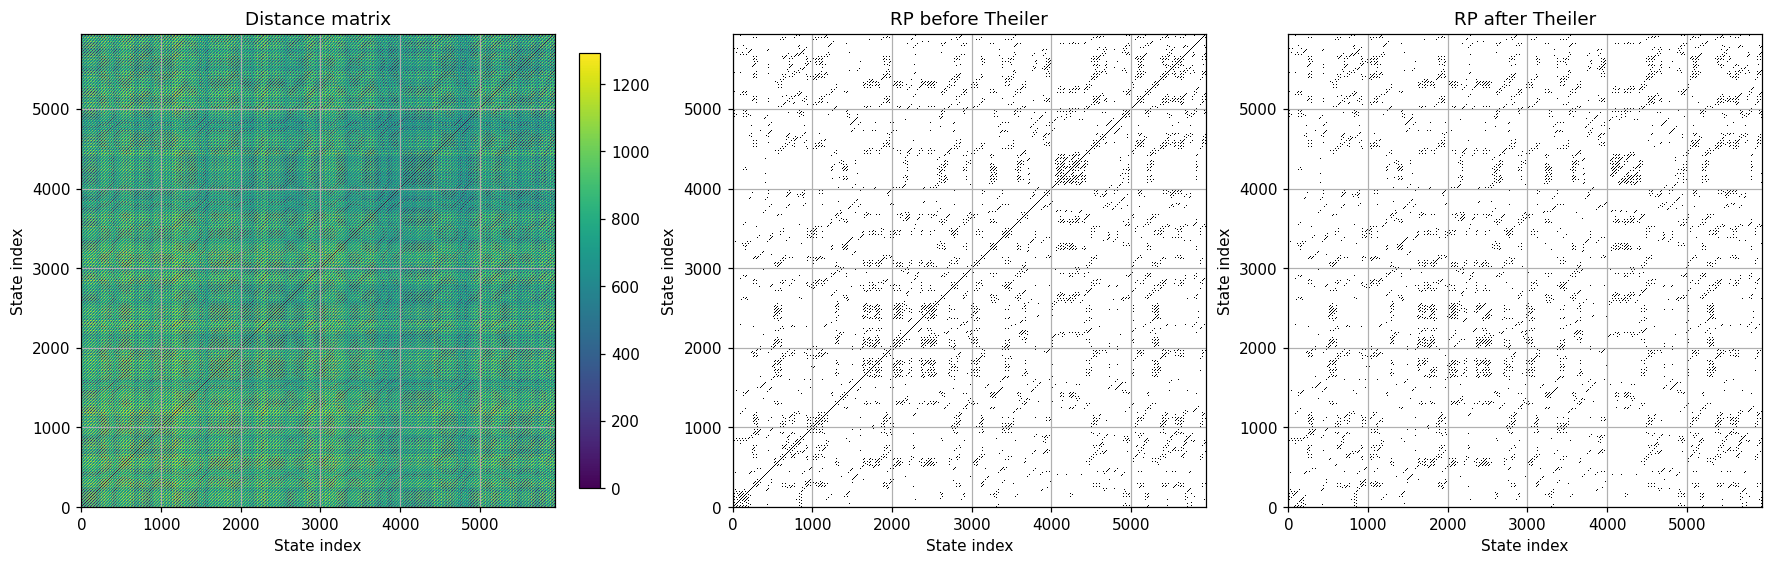

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

distance_image = axes[0].imshow(
    real_distances,
    origin="lower",
    aspect="equal",
    interpolation="nearest",
    cmap="viridis",
)
axes[0].set_title("Distance matrix")
fig.colorbar(distance_image, ax=axes[0], fraction=0.046)

axes[1].imshow(
    real_recurrence_before,
    origin="lower",
    aspect="equal",
    interpolation="nearest",
    cmap="binary",
)
axes[1].set_title("RP before Theiler")

axes[2].imshow(
    real_recurrence_after,
    origin="lower",
    aspect="equal",
    interpolation="nearest",
    cmap="binary",
)
axes[2].set_title("RP after Theiler")

for axis in axes:
    axis.set_xlabel("State index")
    axis.set_ylabel("State index")

plt.show()


## Cell 8 — Theiler implementation

Verify symmetry, the complete exclusion corridor, and removal of the line of identity before continuing.


In [8]:
assert np.array_equal(real_recurrence_after, real_recurrence_after.T)
print("Symmetry: PASS")

theiler_offsets = range(
    -representative_theiler,
    representative_theiler + 1,
)
assert all(
    not np.any(np.diag(real_recurrence_after, k=offset))
    for offset in theiler_offsets
)
print("Theiler mask: PASS")

assert not np.any(np.diag(real_recurrence_after))
print("LOI exclusion: PASS")

del real_states
del real_distances
del real_recurrence_before
del real_recurrence_after
gc.collect()


Symmetry: PASS
Theiler mask: PASS
LOI exclusion: PASS


29

## Cell 9 — Diagonal-line extraction

Use a manually constructed matrix with known diagonal runs.


In [9]:
diagonal_test_matrix = np.zeros((15, 15), dtype=bool)
known_diagonal_lines = [
    (0, 1, 2),
    (1, 5, 3),
    (2, 10, 5),
]
for row, column, length in known_diagonal_lines:
    positions = np.arange(length)
    diagonal_test_matrix[row + positions, column + positions] = True

expected_diagonal_lengths = np.array([2, 3, 5], dtype=np.int32)
detected_diagonal_lengths = np.sort(
    rqa_core.extract_diagonal_lengths(diagonal_test_matrix)
)

print(f"Expected diagonal lengths: {expected_diagonal_lengths.tolist()}")
print(f"Detected diagonal lengths: {detected_diagonal_lengths.tolist()}")
assert np.array_equal(
    detected_diagonal_lengths,
    expected_diagonal_lengths,
)
print("Diagonal extraction test: PASS")


Expected diagonal lengths: [2, 3, 5]
Detected diagonal lengths: [2, 3, 5]
Diagonal extraction test: PASS


## Cell 10 — Vertical-line extraction

Use a second manual matrix with known vertical runs.


In [10]:
vertical_test_matrix = np.zeros((15, 12), dtype=bool)
known_vertical_lines = [
    (0, 1, 2),
    (4, 5, 3),
    (7, 9, 5),
]
for row, column, length in known_vertical_lines:
    vertical_test_matrix[row:row + length, column] = True

expected_vertical_lengths = np.array([2, 3, 5], dtype=np.int32)
detected_vertical_lengths = np.sort(
    rqa_core.extract_vertical_lengths(vertical_test_matrix)
)

print(f"Expected vertical lengths: {expected_vertical_lengths.tolist()}")
print(f"Detected vertical lengths: {detected_vertical_lengths.tolist()}")
assert np.array_equal(
    detected_vertical_lengths,
    expected_vertical_lengths,
)
print("Vertical extraction test: PASS")


Expected vertical lengths: [2, 3, 5]
Detected vertical lengths: [2, 3, 5]
Vertical extraction test: PASS


## Cell 11 — Manual metric formulas

Compare all seven core metrics with direct calculations on the manual line matrices.


In [11]:
manual_l_min = 3
manual_v_min = 3

diagonal_output = rqa_core._diagonal_metrics(
    diagonal_test_matrix,
    detected_diagonal_lengths,
    l_min=manual_l_min,
)
vertical_output = rqa_core._vertical_metrics(
    vertical_test_matrix,
    detected_vertical_lengths,
    v_min=manual_v_min,
)

valid_diagonal = expected_diagonal_lengths[
    expected_diagonal_lengths >= manual_l_min
]
valid_vertical = expected_vertical_lengths[
    expected_vertical_lengths >= manual_v_min
]
manual_diagonal_probabilities = np.full(valid_diagonal.size, 0.5)

manual_values = {
    "DET": valid_diagonal.sum() / expected_diagonal_lengths.sum(),
    "Lmean": valid_diagonal.mean(),
    "ENTR": -np.sum(
        manual_diagonal_probabilities
        * np.log(manual_diagonal_probabilities)
    ),
    "Lmax": valid_diagonal.max(),
    "LAM": valid_vertical.sum() / expected_vertical_lengths.sum(),
    "TT": valid_vertical.mean(),
    "Vmax": valid_vertical.max(),
}
core_values = {
    "DET": diagonal_output[0],
    "Lmean": diagonal_output[1],
    "ENTR": diagonal_output[2],
    "Lmax": diagonal_output[3],
    "LAM": vertical_output[0],
    "TT": vertical_output[1],
    "Vmax": vertical_output[2],
}

for metric, expected in manual_values.items():
    assert np.isclose(core_values[metric], expected)
    print(f"{metric}: PASS")

print("Mathematical core validation: PASS")


DET: PASS
Lmean: PASS
ENTR: PASS
Lmax: PASS
LAM: PASS
TT: PASS
Vmax: PASS
Mathematical core validation: PASS


## Cell 12 — Session 1 baseline RQA

Run every eligible window at `l_min = v_min = 2`. Only compact line-length histograms are cached for later sensitivity analysis.


In [12]:
def compress_lengths(lengths):
    """Return compact line lengths and their occurrence counts."""
    values, counts = np.unique(lengths, return_counts=True)
    return values.astype(np.int32), counts.astype(np.int64)


def eligible_point_count(matrix_size, theiler):
    """Count RP cells outside a symmetric Theiler corridor."""
    width = min(theiler, matrix_size - 1)
    excluded = (
        matrix_size * (2 * width + 1)
        - width * (width + 1)
    )
    return matrix_size * matrix_size - excluded


baseline_rows = []
line_hist_cache = {}
selected_windows = list(iter_selected_windows())

for position, item in enumerate(selected_windows, start=1):
    representation = item["representation"]
    tau = int(round(TAU_SECONDS[representation] * item["fs"]))
    theiler = (M - 1) * tau

    states = rqa_core.reconstruct_phase_space(
        item["signal"],
        m=M,
        tau=tau,
    )
    distances = rqa_core.compute_distance_matrix(states)
    recurrence, epsilon = rqa_core.compute_recurrence_matrix(
        distances,
        radius_fraction=RADIUS_FRACTION,
    )
    del states, distances

    recurrence = rqa_core.apply_theiler_window(
        recurrence,
        theiler=theiler,
    )
    diagonal_lengths = rqa_core.extract_diagonal_lengths(recurrence)
    vertical_lengths = rqa_core.extract_vertical_lengths(recurrence)

    diagonal_metrics = rqa_core._diagonal_metrics(
        recurrence,
        diagonal_lengths,
        l_min=L_MIN_BASE,
    )
    vertical_metrics = rqa_core._vertical_metrics(
        recurrence,
        vertical_lengths,
        v_min=V_MIN_BASE,
    )

    diagonal_values, diagonal_counts = compress_lengths(
        diagonal_lengths
    )
    vertical_values, vertical_counts = compress_lengths(vertical_lengths)
    total_diagonal_points = int(
        np.sum(diagonal_values * diagonal_counts)
    )
    total_vertical_points = int(
        np.sum(vertical_values * vertical_counts)
    )
    eligible_points = eligible_point_count(recurrence.shape[0], theiler)
    recurrence_rate = (
        total_vertical_points / eligible_points
        if eligible_points > 0
        else 0.0
    )

    cache_key = (
        representation,
        item["state"],
        item["window_size"],
        item["window_id"],
    )
    line_hist_cache[cache_key] = {
        "representation": representation,
        "state": item["state"],
        "window_size": item["window_size"],
        "window_id": item["window_id"],
        "fs": item["fs"],
        "tau_samples": tau,
        "theiler_samples": theiler,
        "diagonal_values": diagonal_values,
        "diagonal_counts": diagonal_counts,
        "vertical_values": vertical_values,
        "vertical_counts": vertical_counts,
        "total_diagonal_points": total_diagonal_points,
        "total_vertical_points": total_vertical_points,
    }

    baseline_rows.append(
        {
            "representation": representation,
            "state": item["state"],
            "window_size": item["window_size"],
            "window_id": item["window_id"],
            "fs": item["fs"],
            "tau_samples": tau,
            "theiler_samples": theiler,
            "DET": diagonal_metrics[0],
            "Lmean": diagonal_metrics[1],
            "ENTR": diagonal_metrics[2],
            "Lmax": diagonal_metrics[3],
            "LAM": vertical_metrics[0],
            "TT": vertical_metrics[1],
            "Vmax": vertical_metrics[2],
            "RR": recurrence_rate,
            "epsilon": epsilon,
            "n_diagonal_lines": diagonal_metrics[4],
            "n_vertical_lines": vertical_metrics[3],
        }
    )

    del recurrence, diagonal_lengths, vertical_lengths
    if position % 10 == 0 or position == len(selected_windows):
        print(f"Processed {position}/{len(selected_windows)} windows")
        gc.collect()

baseline_df = pd.DataFrame(baseline_rows)
print(f"Baseline shape: {baseline_df.shape}")
display(baseline_df.head())
display(
    baseline_df.groupby(
        ["representation", "state", "window_size"],
        observed=True,
    )
    .size()
    .rename("n_valid_windows")
    .reset_index()
)


Processed 10/105 windows


Processed 20/105 windows


Processed 30/105 windows


Processed 40/105 windows


Processed 50/105 windows


...

Processed 90/105 windows


Processed 100/105 windows


Processed 105/105 windows
Baseline shape: (105, 18)


,representation,state,window_size,window_id,fs,tau_samples,theiler_samples,DET,Lmean,ENTR,Lmax,LAM,TT,Vmax,RR,epsilon,n_diagonal_lines,n_vertical_lines
0,Processed,Awake,60,1,50.0,8,56,0.916575,4.893671,1.965217,170,0.722476,2.493449,5,0.026065,129.322986,20352,62969
1,Processed,Awake,60,2,50.0,8,56,0.921714,4.959562,1.957209,176,0.771511,2.586296,5,0.025567,121.410588,19808,63589
2,Processed,Awake,60,3,50.0,8,56,0.917547,4.713732,1.928988,175,0.773202,2.576912,5,0.024481,124.407805,19866,61245
3,Processed,Awake,60,4,50.0,8,56,0.939486,5.624342,2.077824,192,0.715773,2.395730,5,0.029179,119.673045,20319,72686
4,Processed,Awake,60,5,50.0,8,56,0.921582,4.924531,1.958587,234,0.710293,2.421268,6,0.024814,117.893864,19359,60693


,representation,state,window_size,n_valid_windows
0,Processed,Awake,60,24
1,Processed,Awake,120,11
2,Processed,Awake,180,6
3,Processed,Drowsy,60,7
4,Processed,Drowsy,120,1
5,Processed,Drowsy,180,1
6,Raw,Awake,60,24
7,Raw,Awake,120,11
8,Raw,Awake,180,6
9,Raw,Drowsy,60,10


## Cell 13 — Baseline quality diagnostics

Check finite output, bounds, line support, recurrence rate, and internal ordering constraints across Session 1.


In [13]:
metric_columns = [
    "DET",
    "Lmean",
    "ENTR",
    "Lmax",
    "LAM",
    "TT",
    "Vmax",
    "RR",
    "epsilon",
]
metric_values = baseline_df[metric_columns].to_numpy(dtype=float)
invalid_mask = ~np.isfinite(metric_values).all(axis=1)
invalid_mask |= ~baseline_df["DET"].between(0.0, 1.0)
invalid_mask |= ~baseline_df["LAM"].between(0.0, 1.0)
invalid_mask |= ~baseline_df["RR"].between(0.0, 1.0)
invalid_mask |= baseline_df["epsilon"] <= 0.0
invalid_mask |= (
    (baseline_df["n_diagonal_lines"] > 0)
    & (baseline_df["Lmax"] < baseline_df["Lmean"])
)
invalid_mask |= (
    (baseline_df["n_vertical_lines"] > 0)
    & (baseline_df["Vmax"] < baseline_df["TT"])
)

baseline_qc = pd.Series(
    {
        "Windows tested": len(baseline_df),
        "Invalid outputs": int(invalid_mask.sum()),
        "Zero diagonal support": int(
            (baseline_df["n_diagonal_lines"] == 0).sum()
        ),
        "Zero vertical support": int(
            (baseline_df["n_vertical_lines"] == 0).sum()
        ),
        "Pathological RR": int(
            ((baseline_df["RR"] <= 0.0) | (baseline_df["RR"] >= 1.0)).sum()
        ),
        "RR minimum": baseline_df["RR"].min(),
        "RR maximum": baseline_df["RR"].max(),
    },
    name="value",
)
display(baseline_qc.to_frame())

if invalid_mask.any():
    display(baseline_df.loc[invalid_mask])
    raise AssertionError("Baseline RQA produced invalid outputs.")


,value
Windows tested,105.000000
Invalid outputs,0.000000
Zero diagonal support,0.000000
Zero vertical support,0.000000
Pathological RR,0.000000
RR minimum,0.012474
RR maximum,0.514886


## Cell 14 — Diagonal cutoff protocol

Define the `l_min` grid. Vertical metrics remain fixed and are not recomputed in this phase.


In [14]:
L_MIN_GRID = (2, 3, 4, 5)

print("Diagonal sensitivity protocol")
print(f"l_min grid = {L_MIN_GRID}")
print(f"v_min fixed at {V_MIN_BASE}")
print("Phase space, RP, and line extraction are reused per window.")


Diagonal sensitivity protocol
l_min grid = (2, 3, 4, 5)
v_min fixed at 2
Phase space, RP, and line extraction are reused per window.


## Cell 15 — Run diagonal sensitivity

Evaluate diagonal metrics from the cached length histograms for every candidate cutoff.


In [15]:
def histogram_entropy(counts):
    """Compute Shannon entropy from positive histogram counts."""
    if counts.size == 0:
        return 0.0
    probabilities = counts / counts.sum()
    return float(-np.sum(probabilities * np.log(probabilities)))


def diagonal_metrics_from_histogram(cache, l_min):
    """Evaluate diagonal metrics from one cached histogram."""
    values = cache["diagonal_values"]
    counts = cache["diagonal_counts"]
    selected = values >= l_min
    valid_values = values[selected]
    valid_counts = counts[selected]
    valid_line_count = int(valid_counts.sum())
    valid_points = int(np.sum(valid_values * valid_counts))
    total_points = cache["total_diagonal_points"]
    det = valid_points / total_points if total_points else 0.0

    if valid_line_count == 0:
        return det, 0.0, 0.0, 0, 0, 0.0

    return (
        det,
        valid_points / valid_line_count,
        histogram_entropy(valid_counts),
        int(valid_values.max()),
        valid_line_count,
        valid_points / total_points,
    )


diagonal_sensitivity_rows = []
for cache in line_hist_cache.values():
    for l_min in L_MIN_GRID:
        metrics = diagonal_metrics_from_histogram(cache, l_min)
        diagonal_sensitivity_rows.append(
            {
                "representation": cache["representation"],
                "state": cache["state"],
                "window_size": cache["window_size"],
                "window_id": cache["window_id"],
                "l_min": l_min,
                "DET": metrics[0],
                "Lmean": metrics[1],
                "ENTR": metrics[2],
                "Lmax": metrics[3],
                "n_valid_diagonal_lines": metrics[4],
                "fraction_valid_diagonal_points": metrics[5],
            }
        )

diagonal_sensitivity_df = pd.DataFrame(diagonal_sensitivity_rows)
print(f"Diagonal sensitivity shape: {diagonal_sensitivity_df.shape}")
display(diagonal_sensitivity_df.head())


Diagonal sensitivity shape: (420, 11)


,representation,state,window_size,window_id,l_min,DET,Lmean,ENTR,Lmax,n_valid_diagonal_lines,fraction_valid_diagonal_points
0,Processed,Awake,60,1,2,0.916575,4.893671,1.965217,170,20352,0.916575
1,Processed,Awake,60,1,3,0.780703,6.540632,2.055994,170,12970,0.780703
2,Processed,Awake,60,1,4,0.655497,8.444221,2.166170,170,8435,0.655497
3,Processed,Awake,60,1,5,0.542338,10.992539,2.376218,170,5361,0.542338
4,Processed,Awake,60,2,2,0.921714,4.959562,1.957209,176,19808,0.921714


## Cell 16 — Aggregate diagonal sensitivity

Summarize metric location, spread, line count, and retained recurrence support across windows.


In [16]:
def aggregate_sensitivity(data, group_columns, metrics, support_columns):
    """Aggregate sensitivity metrics with robust spread summaries."""
    aggregations = {}
    for metric in metrics:
        aggregations[f"{metric}_mean"] = (metric, "mean")
        aggregations[f"{metric}_median"] = (metric, "median")
        aggregations[f"{metric}_std"] = (metric, "std")
        aggregations[f"{metric}_q25"] = (
            metric,
            lambda values: values.quantile(0.25),
        )
        aggregations[f"{metric}_q75"] = (
            metric,
            lambda values: values.quantile(0.75),
        )
    for column in support_columns:
        aggregations[f"{column}_mean"] = (column, "mean")

    return (
        data.groupby(group_columns, observed=True)
        .agg(**aggregations)
        .reset_index()
    )


diagonal_summary = aggregate_sensitivity(
    diagonal_sensitivity_df,
    ["representation", "state", "window_size", "l_min"],
    ["DET", "Lmean", "ENTR", "Lmax"],
    [
        "n_valid_diagonal_lines",
        "fraction_valid_diagonal_points",
    ],
)
display(diagonal_summary)


,representation,state,window_size,l_min,DET_mean,DET_median,DET_std,DET_q25,DET_q75,Lmean_mean,Lmean_median,Lmean_std,Lmean_q25,Lmean_q75,ENTR_mean,ENTR_median,ENTR_std,ENTR_q25,ENTR_q75,Lmax_mean,Lmax_median,Lmax_std,Lmax_q25,Lmax_q75,n_valid_diagonal_lines_mean,fraction_valid_diagonal_points_mean
0,Processed,Awake,60,2,0.921166,0.924436,0.015963,0.917304,0.927586,5.048437,5.053120,0.395582,4.851996,5.276714,1.953939,1.957898,0.091510,1.926524,2.000658,197.375000,196.0,32.873688,172.25,215.00,17075.541667,0.921166
1,Processed,Awake,60,3,0.784765,0.787836,0.033194,0.778955,0.797452,6.836989,6.822629,0.527171,6.496824,7.197766,2.058119,2.065920,0.101524,2.018348,2.113398,197.375000,196.0,32.873688,172.25,215.00,10814.375000,0.784765
2,Processed,Awake,60,4,0.657439,0.657862,0.042757,0.649844,0.673792,9.071012,8.949175,0.772902,8.463728,9.694404,2.217495,2.188944,0.134748,2.148709,2.302144,197.375000,196.0,32.873688,172.25,215.00,6873.791667,0.657439
3,Processed,Awake,60,5,0.548857,0.553205,0.046812,0.535147,0.572349,12.076356,11.951369,1.089518,11.245193,12.684931,2.482660,2.479859,0.175000,2.382216,2.582506,197.375000,196.0,32.873688,172.25,215.00,4319.500000,0.548857
4,Processed,Awake,120,2,0.921147,0.924230,0.012111,0.918231,0.929174,5.035598,5.064108,0.300854,4.922867,5.131946,1.961670,1.969567,0.058055,1.936120,2.008010,251.272727,253.0,33.196659,236.00,266.00,69088.454545,0.921147
5,Processed,Awake,120,3,0.784932,0.790615,0.023559,0.781633,0.802140,6.827250,6.684170,0.465496,6.578038,6.996100,2.071717,2.057456,0.071256,2.039489,2.081251,251.272727,253.0,33.196659,236.00,266.00,43625.181818,0.784932
6,Processed,Awake,120,4,0.657869,0.661065,0.029358,0.651977,0.681012,9.057504,8.708889,0.769094,8.547852,9.400447,2.237829,2.193082,0.116862,2.164200,2.255148,251.272727,253.0,33.196659,236.00,266.00,27687.181818,0.657869
7,Processed,Awake,120,5,0.549492,0.551239,0.033948,0.539429,0.565665,12.022936,11.444631,1.046032,11.270876,12.566328,2.507673,2.467426,0.143919,2.415365,2.531846,251.272727,253.0,33.196659,236.00,266.00,17412.363636,0.549492
8,Processed,Awake,180,2,0.922121,0.924558,0.012700,0.911274,0.931039,5.059743,4.969494,0.347031,4.815560,5.203938,1.970985,1.978195,0.057650,1.923323,2.008943,251.666667,255.5,17.119190,237.25,265.50,166864.333333,0.922121
9,Processed,Awake,180,3,0.788548,0.793851,0.024700,0.767597,0.808475,6.817140,6.622906,0.512029,6.491468,6.872102,2.071384,2.049733,0.068313,2.033996,2.077795,251.666667,255.5,17.119190,237.25,265.50,106214.500000,0.788548


## Cell 17 — Diagonal metrics versus l_min

Plot each diagonal metric separately. Panels separate representation and duration; lines show state only where coverage exists.


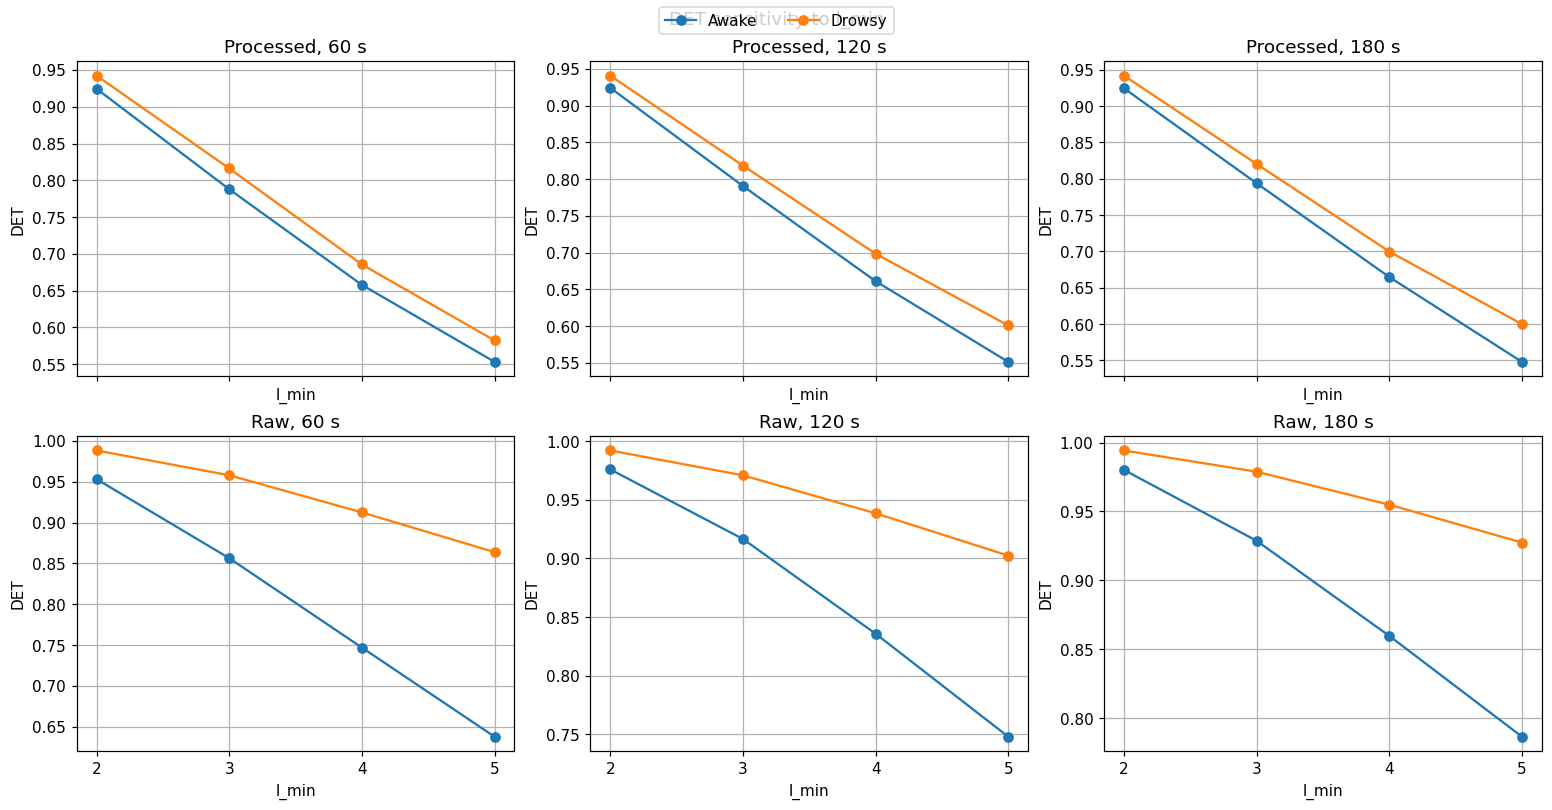

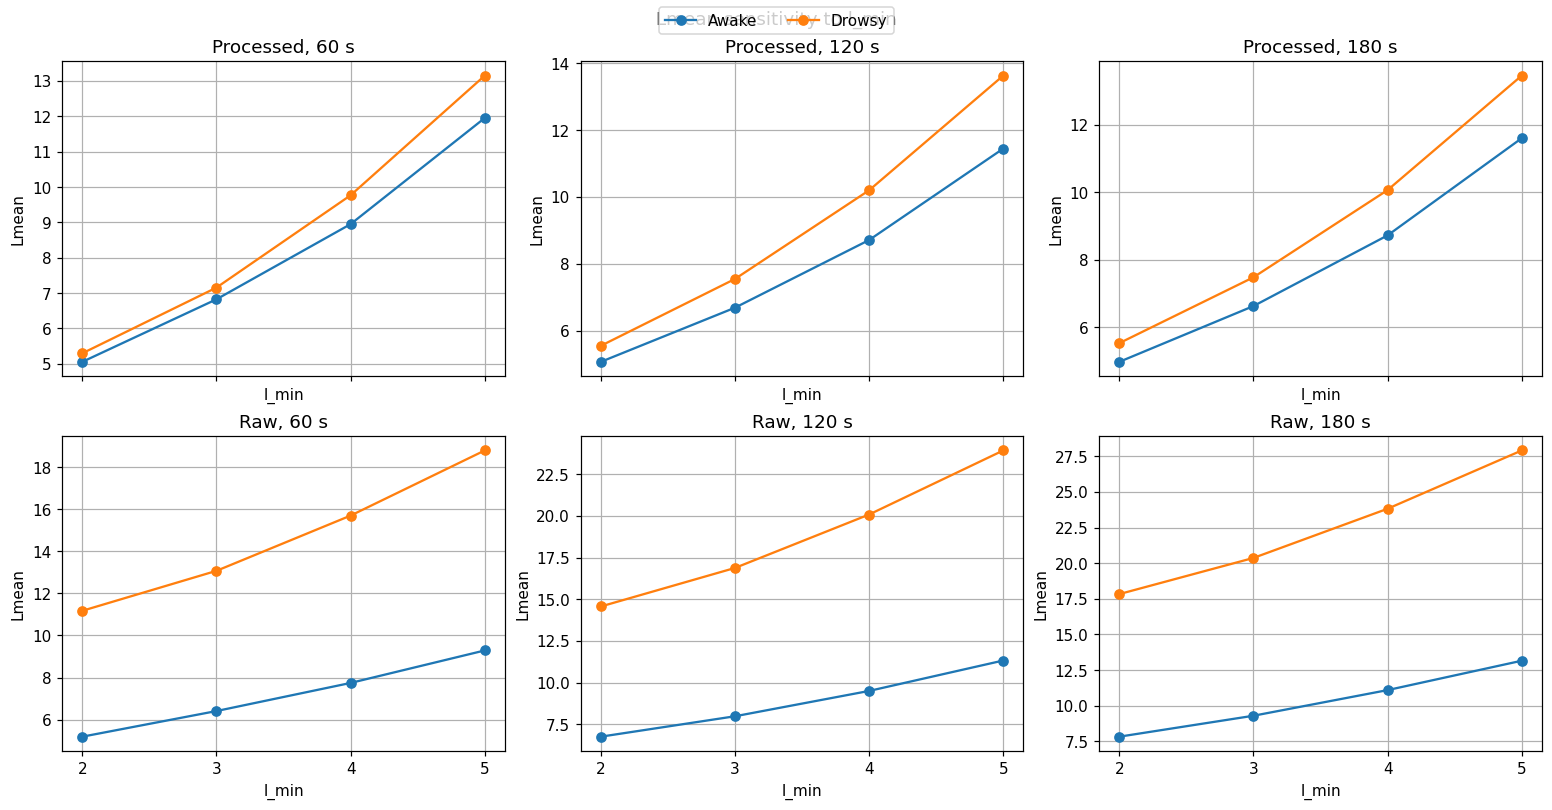

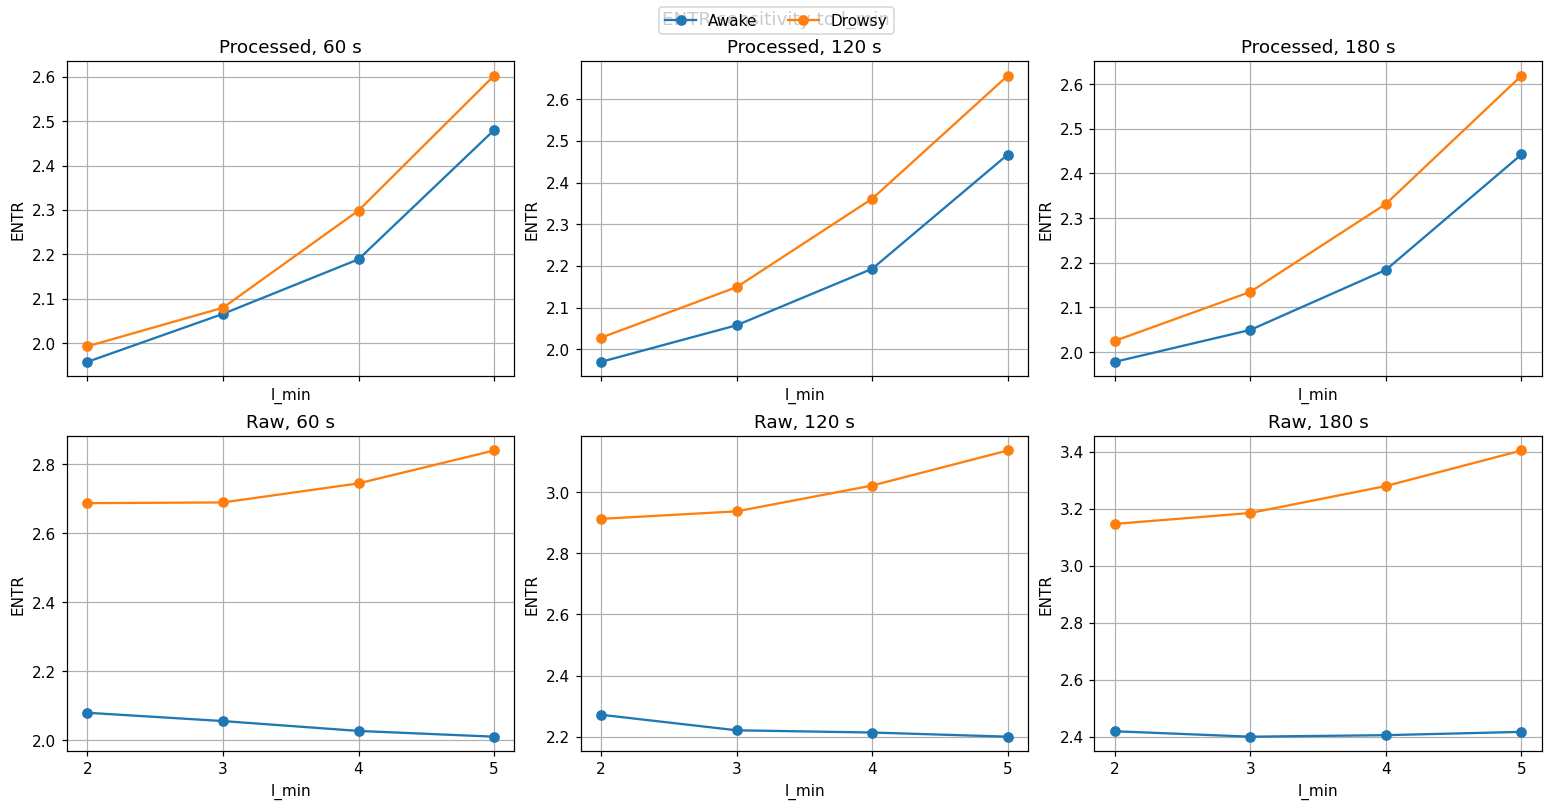

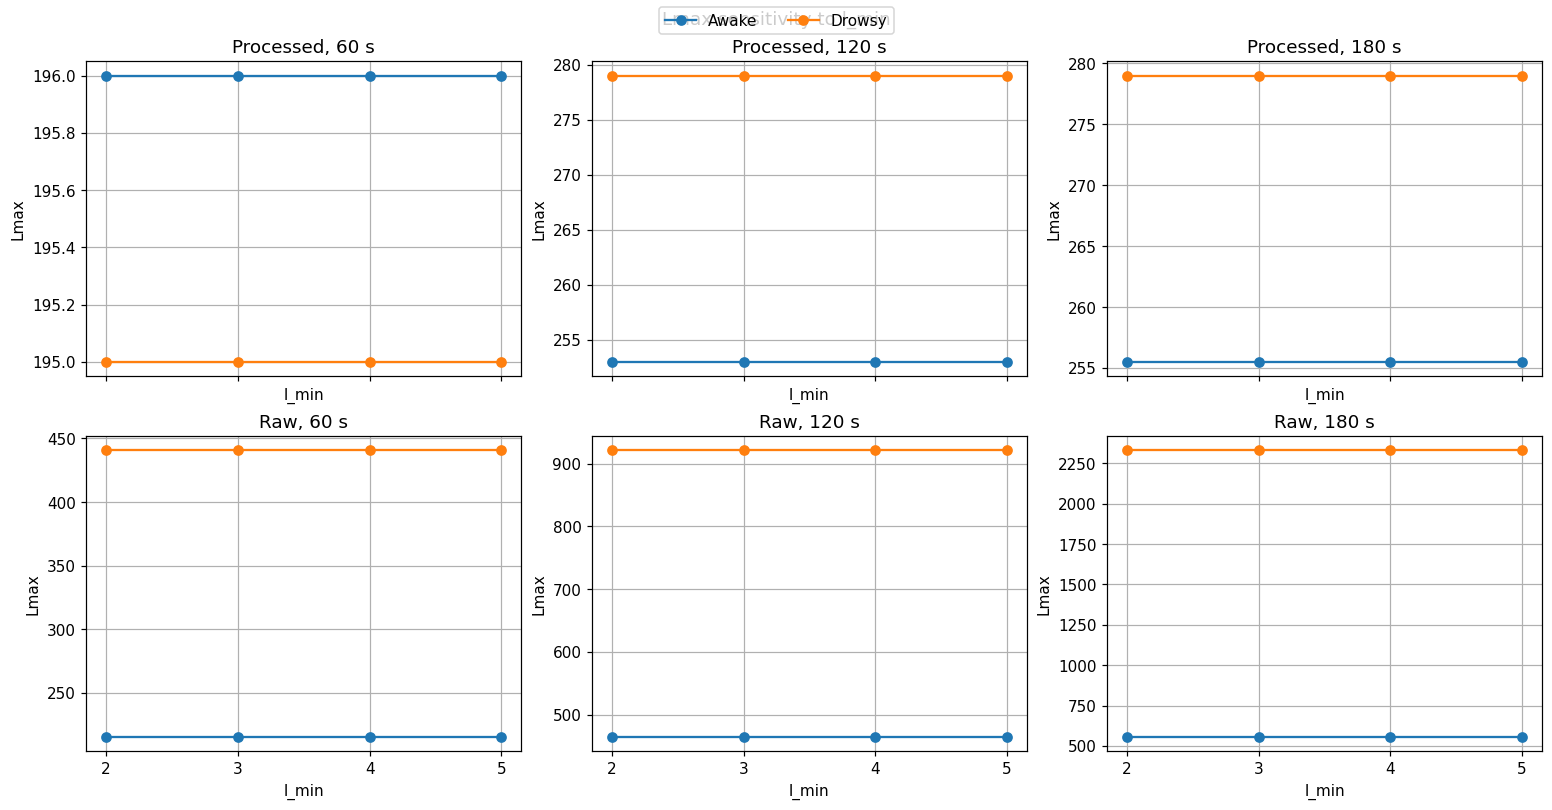

In [17]:
def plot_metric_grid(summary, cutoff, metric, title):
    """Plot one metric by representation, duration, and state."""
    representations = ("Processed", "Raw")
    fig, axes = plt.subplots(
        len(representations),
        len(WINDOW_SIZES),
        figsize=(14, 7),
        sharex=True,
        constrained_layout=True,
    )
    colors = {"Awake": "tab:blue", "Drowsy": "tab:orange"}

    for row, representation in enumerate(representations):
        for column, window_size in enumerate(WINDOW_SIZES):
            axis = axes[row, column]
            panel = summary.loc[
                (summary["representation"] == representation)
                & (summary["window_size"] == window_size)
            ]
            for state in ("Awake", "Drowsy"):
                values = panel.loc[panel["state"] == state]
                if values.empty:
                    continue
                axis.plot(
                    values[cutoff],
                    values[f"{metric}_median"],
                    marker="o",
                    color=colors[state],
                    label=state,
                )
            if panel.empty:
                axis.text(
                    0.5,
                    0.5,
                    "No eligible windows",
                    ha="center",
                    va="center",
                    transform=axis.transAxes,
                )
            axis.set_title(f"{representation}, {window_size} s")
            axis.set_xlabel(cutoff)
            axis.set_ylabel(metric)
            axis.set_xticks(sorted(summary[cutoff].unique()))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(title, y=1.03)
    plt.show()


for diagonal_metric in ("DET", "Lmean", "ENTR", "Lmax"):
    plot_metric_grid(
        diagonal_summary,
        cutoff="l_min",
        metric=diagonal_metric,
        title=f"{diagonal_metric} sensitivity to l_min",
    )


## Cell 18 — Diagonal support versus l_min

Show the number of qualifying lines and the fraction of diagonal recurrence points retained.


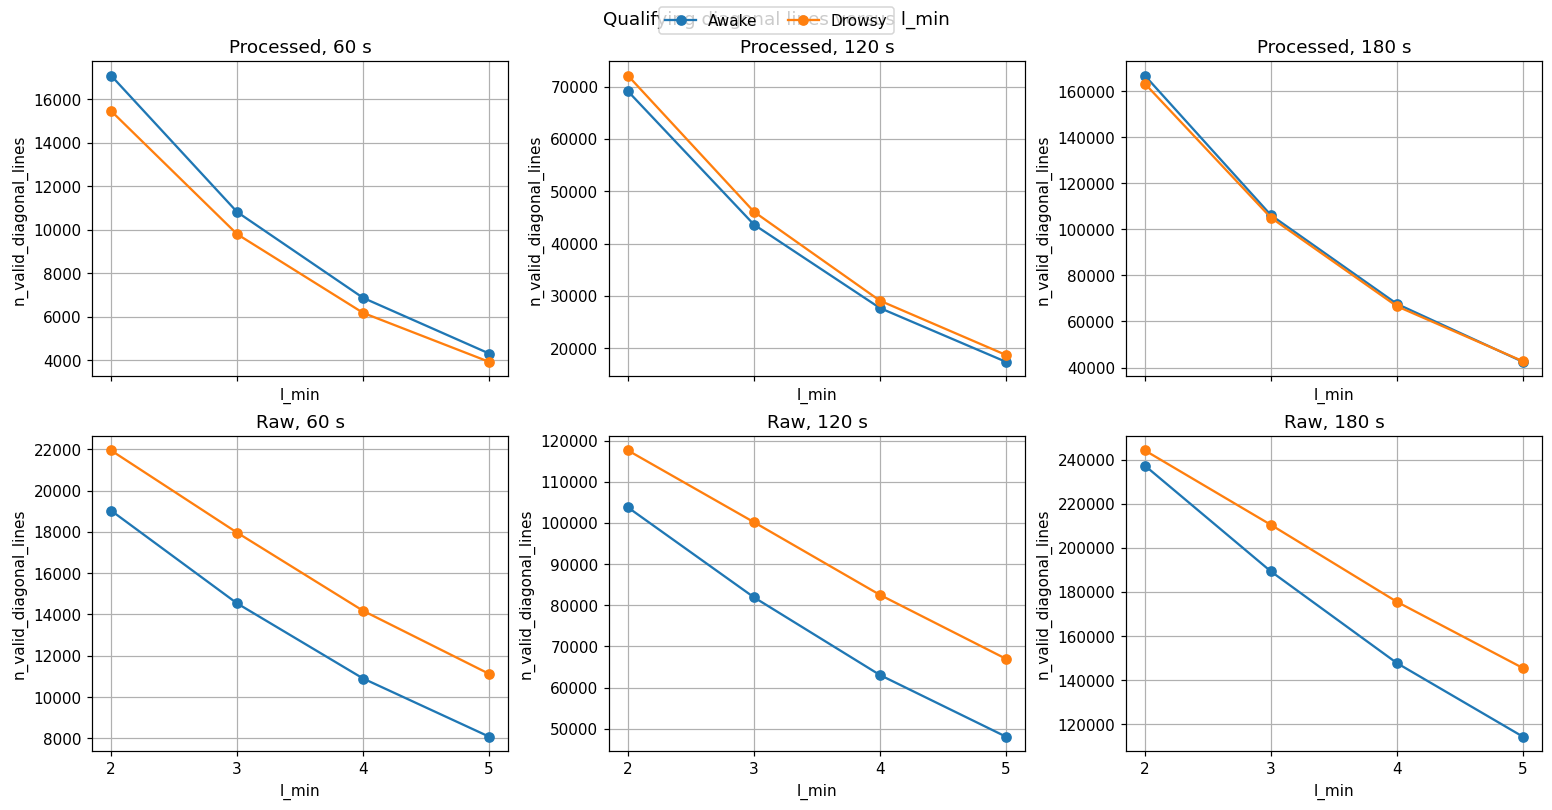

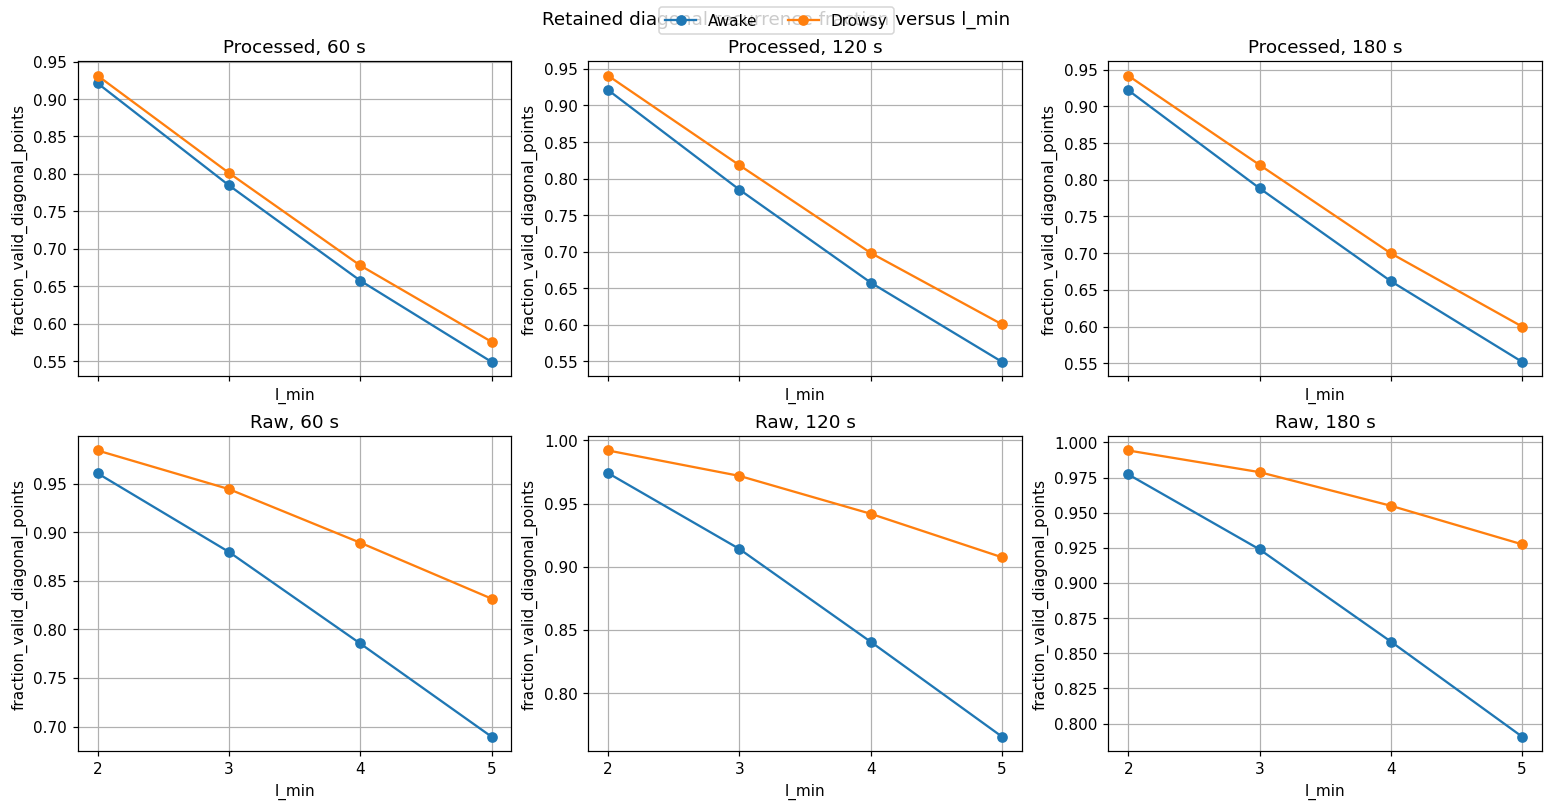

In [18]:
for support_metric, support_label in (
    ("n_valid_diagonal_lines", "Qualifying diagonal lines"),
    (
        "fraction_valid_diagonal_points",
        "Retained diagonal recurrence fraction",
    ),
):
    plot_metric_grid(
        diagonal_summary.rename(
            columns={f"{support_metric}_mean": f"{support_metric}_median"}
        ),
        cutoff="l_min",
        metric=support_metric,
        title=f"{support_label} versus l_min",
    )


## Cell 19 — Numerical diagonal sensitivity

Use `l_min = 2` as the within-window reference and report median relative metric change together with support retention.


In [19]:
def relative_changes(data, cutoff, metrics, baseline=2, delta=1e-12):
    """Return within-window relative changes from a baseline cutoff."""
    key_columns = [
        "representation",
        "state",
        "window_size",
        "window_id",
    ]
    rows = []
    for metric in metrics:
        reference = (
            data.loc[data[cutoff] == baseline, key_columns + [metric]]
            .rename(columns={metric: "reference"})
        )
        compared = data[key_columns + [cutoff, metric]].merge(
            reference,
            on=key_columns,
            how="inner",
            validate="many_to_one",
        )
        compared["metric"] = metric
        compared["relative_change"] = (
            (compared[metric] - compared["reference"]).abs()
            / (compared["reference"].abs() + delta)
        )
        rows.append(
            compared[
                key_columns
                + [cutoff, "metric", "relative_change"]
            ]
        )
    return pd.concat(rows, ignore_index=True)


diagonal_relative_long = relative_changes(
    diagonal_sensitivity_df,
    cutoff="l_min",
    metrics=["DET", "Lmean", "ENTR", "Lmax"],
)
diagonal_relative_table = (
    diagonal_relative_long.groupby(["metric", "l_min"], observed=True)
    ["relative_change"]
    .median()
    .unstack("l_min")
)
diagonal_support_table = (
    diagonal_sensitivity_df.groupby("l_min", observed=True)
    .agg(
        median_point_retention=(
            "fraction_valid_diagonal_points",
            "median",
        ),
        median_line_count=("n_valid_diagonal_lines", "median"),
        zero_support_windows=(
            "n_valid_diagonal_lines",
            lambda values: int((values == 0).sum()),
        ),
    )
)

display(diagonal_relative_table)
display(diagonal_support_table)


l_min,2,3,4,5
metric,,,,
DET,0.0,0.115470,0.234165,0.349285
ENTR,0.0,0.028361,0.071143,0.118444
Lmax,0.0,0.000000,0.000000,0.000000
Lmean,0.0,0.265279,0.548098,0.841493


,median_point_retention,median_line_count,zero_support_windows
l_min,,,
2,0.944457,21305.0,0
3,0.836557,16703.0,0
4,0.722011,12745.0,0
5,0.615352,9637.0,0


## Cell 20 — Vertical cutoff protocol

Define the `v_min` grid. Diagonal metrics remain fixed and are not recomputed in this phase.


In [20]:
V_MIN_GRID = (2, 3, 4, 5, 6)

print("Vertical sensitivity protocol")
print(f"v_min grid = {V_MIN_GRID}")
print(f"l_min fixed at {L_MIN_BASE}")
print("Phase space, RP, and line extraction are reused per window.")


Vertical sensitivity protocol
v_min grid = (2, 3, 4, 5, 6)
l_min fixed at 2
Phase space, RP, and line extraction are reused per window.


## Cell 21 — Run vertical sensitivity

Evaluate vertical metrics from the cached length histograms for every candidate cutoff.


In [21]:
def vertical_metrics_from_histogram(cache, v_min):
    """Evaluate vertical metrics from one cached histogram."""
    values = cache["vertical_values"]
    counts = cache["vertical_counts"]
    selected = values >= v_min
    valid_values = values[selected]
    valid_counts = counts[selected]
    valid_line_count = int(valid_counts.sum())
    valid_points = int(np.sum(valid_values * valid_counts))
    total_points = cache["total_vertical_points"]
    lam = valid_points / total_points if total_points else 0.0

    if valid_line_count == 0:
        return lam, 0.0, 0, 0, 0.0

    return (
        lam,
        valid_points / valid_line_count,
        int(valid_values.max()),
        valid_line_count,
        valid_points / total_points,
    )


vertical_sensitivity_rows = []
for cache in line_hist_cache.values():
    for v_min in V_MIN_GRID:
        metrics = vertical_metrics_from_histogram(cache, v_min)
        vertical_sensitivity_rows.append(
            {
                "representation": cache["representation"],
                "state": cache["state"],
                "window_size": cache["window_size"],
                "window_id": cache["window_id"],
                "v_min": v_min,
                "LAM": metrics[0],
                "TT": metrics[1],
                "Vmax": metrics[2],
                "n_valid_vertical_lines": metrics[3],
                "fraction_valid_vertical_points": metrics[4],
            }
        )

vertical_sensitivity_df = pd.DataFrame(vertical_sensitivity_rows)
print(f"Vertical sensitivity shape: {vertical_sensitivity_df.shape}")
display(vertical_sensitivity_df.head())


Vertical sensitivity shape: (525, 10)


,representation,state,window_size,window_id,v_min,LAM,TT,Vmax,n_valid_vertical_lines,fraction_valid_vertical_points
0,Processed,Awake,60,1,2,0.722476,2.493449,5,62969,0.722476
1,Processed,Awake,60,1,3,0.367436,3.273965,5,24390,0.367436
2,Processed,Awake,60,1,4,0.119206,4.042759,5,6408,0.119206
3,Processed,Awake,60,1,5,0.006304,5.000000,5,274,0.006304
4,Processed,Awake,60,1,6,0.000000,0.000000,0,0,0.000000


## Cell 22 — Aggregate vertical sensitivity

Summarize vertical metric location, spread, line count, and point retention across windows.


In [22]:
vertical_summary = aggregate_sensitivity(
    vertical_sensitivity_df,
    ["representation", "state", "window_size", "v_min"],
    ["LAM", "TT", "Vmax"],
    [
        "n_valid_vertical_lines",
        "fraction_valid_vertical_points",
    ],
)
display(vertical_summary)


,representation,state,window_size,v_min,LAM_mean,LAM_median,LAM_std,LAM_q25,LAM_q75,TT_mean,TT_median,TT_std,TT_q25,TT_q75,Vmax_mean,Vmax_median,Vmax_std,Vmax_q25,Vmax_q75,n_valid_vertical_lines_mean,fraction_valid_vertical_points_mean
0,Processed,Awake,60,2,0.772305,0.766734,0.046264,0.750191,0.789891,2.539324,2.527792,0.146639,2.439032,2.579258,5.958333,6.0,1.197068,5.00,6.00,57277.500000,0.772305
1,Processed,Awake,60,3,0.399382,0.399701,0.078641,0.344825,0.443795,3.371928,3.329118,0.146636,3.276716,3.412055,5.958333,6.0,1.197068,5.00,6.00,21909.750000,0.399382
2,Processed,Awake,60,4,0.157799,0.165698,0.065171,0.112329,0.174838,4.171983,4.080417,0.184773,4.051543,4.205389,5.958333,6.0,1.197068,5.00,6.00,6755.333333,0.157799
3,Processed,Awake,60,5,0.032789,0.015714,0.039849,0.007920,0.035734,5.117780,5.007927,0.242671,5.000000,5.096977,5.958333,6.0,1.197068,5.00,6.00,953.083333,0.032789
4,Processed,Awake,60,6,0.010422,0.000091,0.025126,0.000000,0.004688,3.542118,6.000000,3.060950,0.000000,6.000000,3.875000,6.0,3.455462,0.00,6.00,224.041667,0.010422
5,Processed,Awake,120,2,0.783407,0.762262,0.041502,0.754446,0.815600,2.546918,2.566146,0.074231,2.486374,2.594808,7.090909,7.0,1.445998,6.00,7.50,232003.636364,0.783407
6,Processed,Awake,120,3,0.409469,0.417681,0.048775,0.368417,0.457444,3.391439,3.393429,0.087138,3.327862,3.434192,7.090909,7.0,1.445998,6.00,7.50,90719.363636,0.409469
7,Processed,Awake,120,4,0.167675,0.161627,0.038933,0.131268,0.198514,4.177538,4.170928,0.114116,4.072355,4.246572,7.090909,7.0,1.445998,6.00,7.50,29852.636364,0.167675
8,Processed,Awake,120,5,0.032498,0.032102,0.022913,0.012448,0.045071,5.166784,5.105277,0.200532,5.005985,5.256947,7.090909,7.0,1.445998,6.00,7.50,4476.181818,0.032498
9,Processed,Awake,120,6,0.007644,0.002956,0.009789,0.000076,0.011561,5.591833,6.042667,1.866389,6.000000,6.166858,6.636364,7.0,2.540580,6.00,7.50,861.727273,0.007644


## Cell 23 — Vertical metrics versus v_min

Plot LAM, trapping time, and maximum vertical length separately.


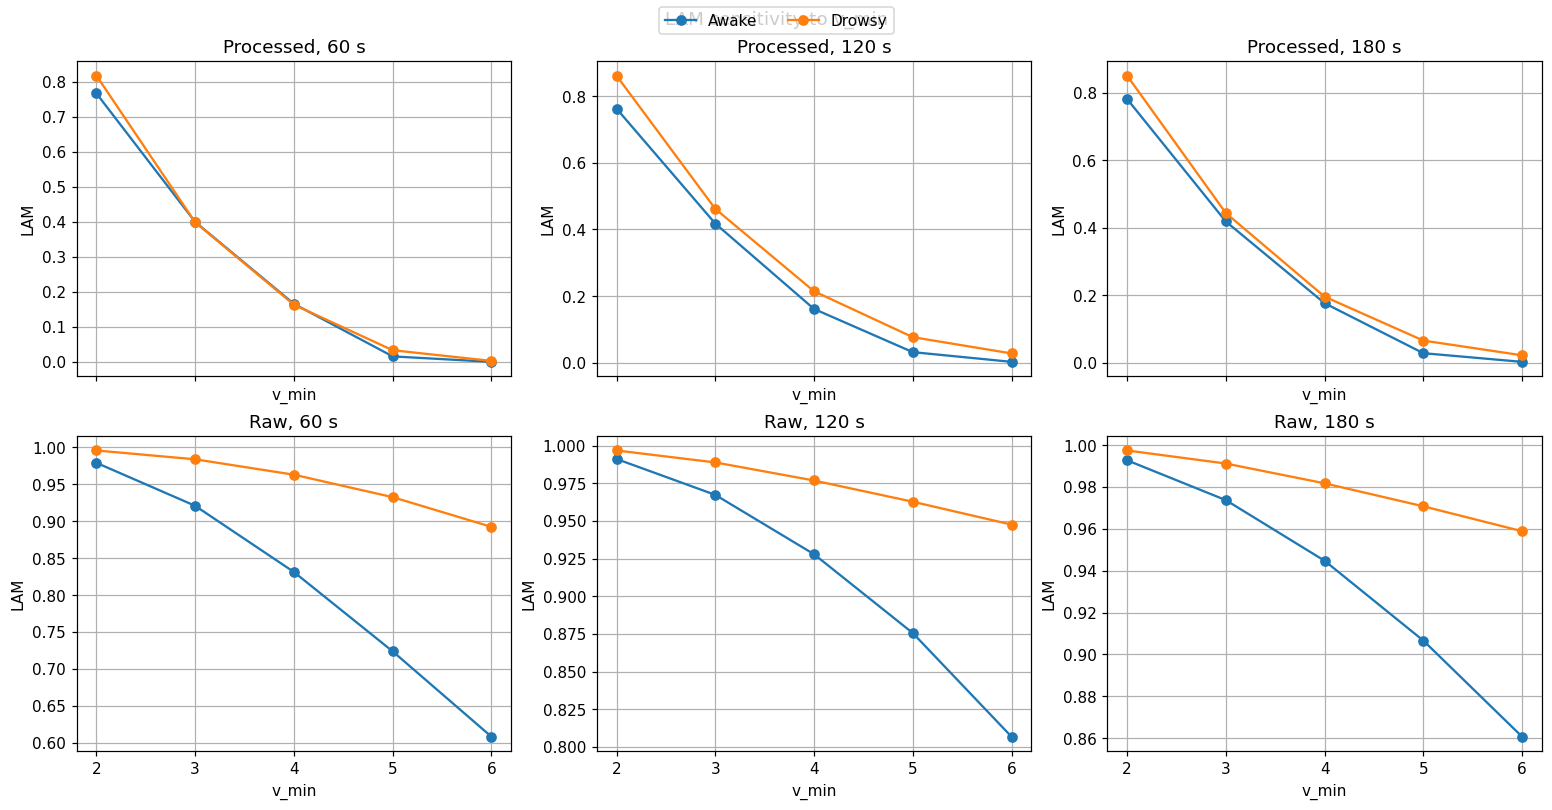

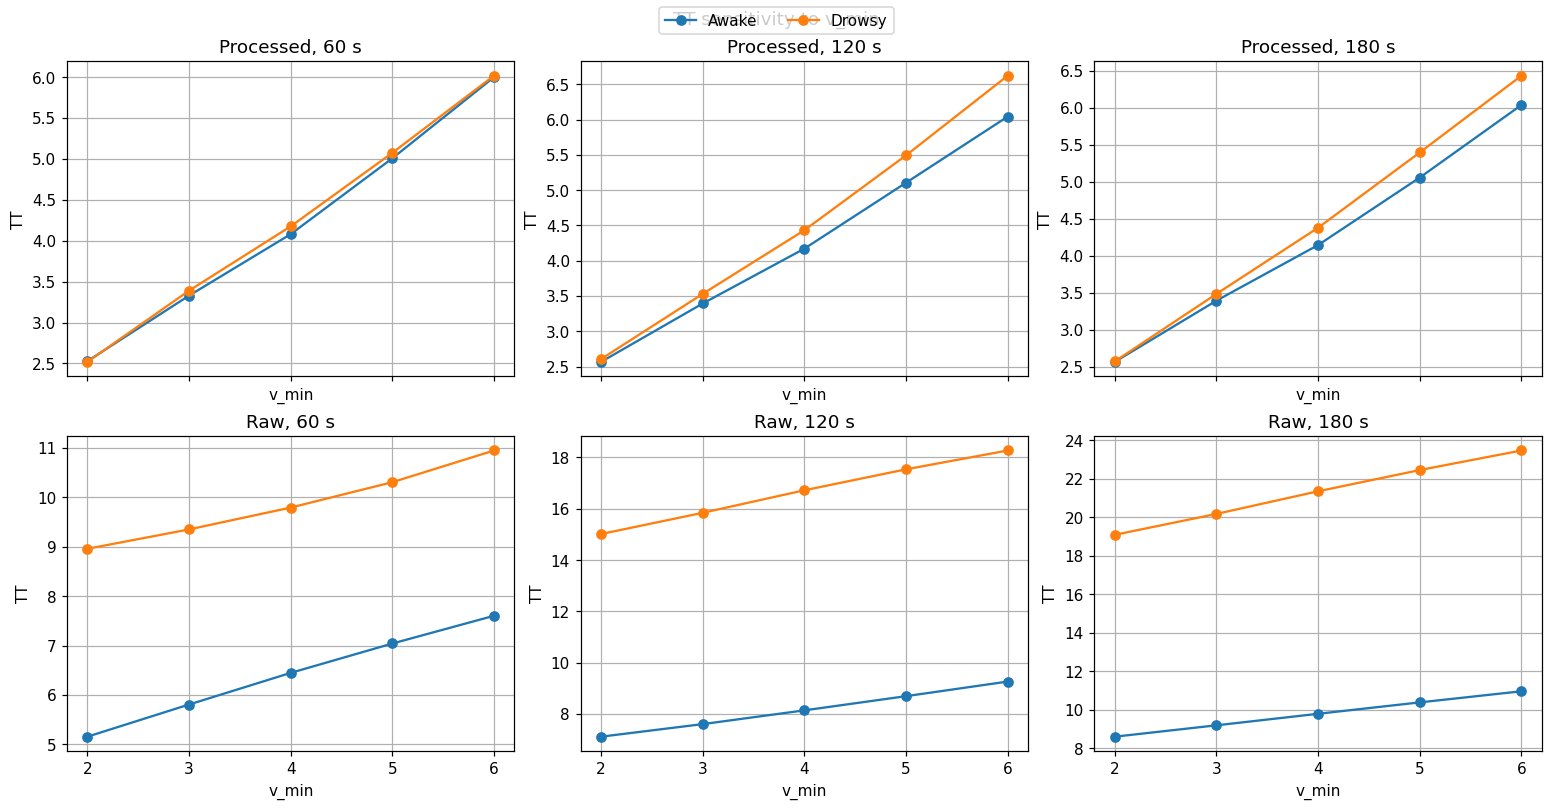

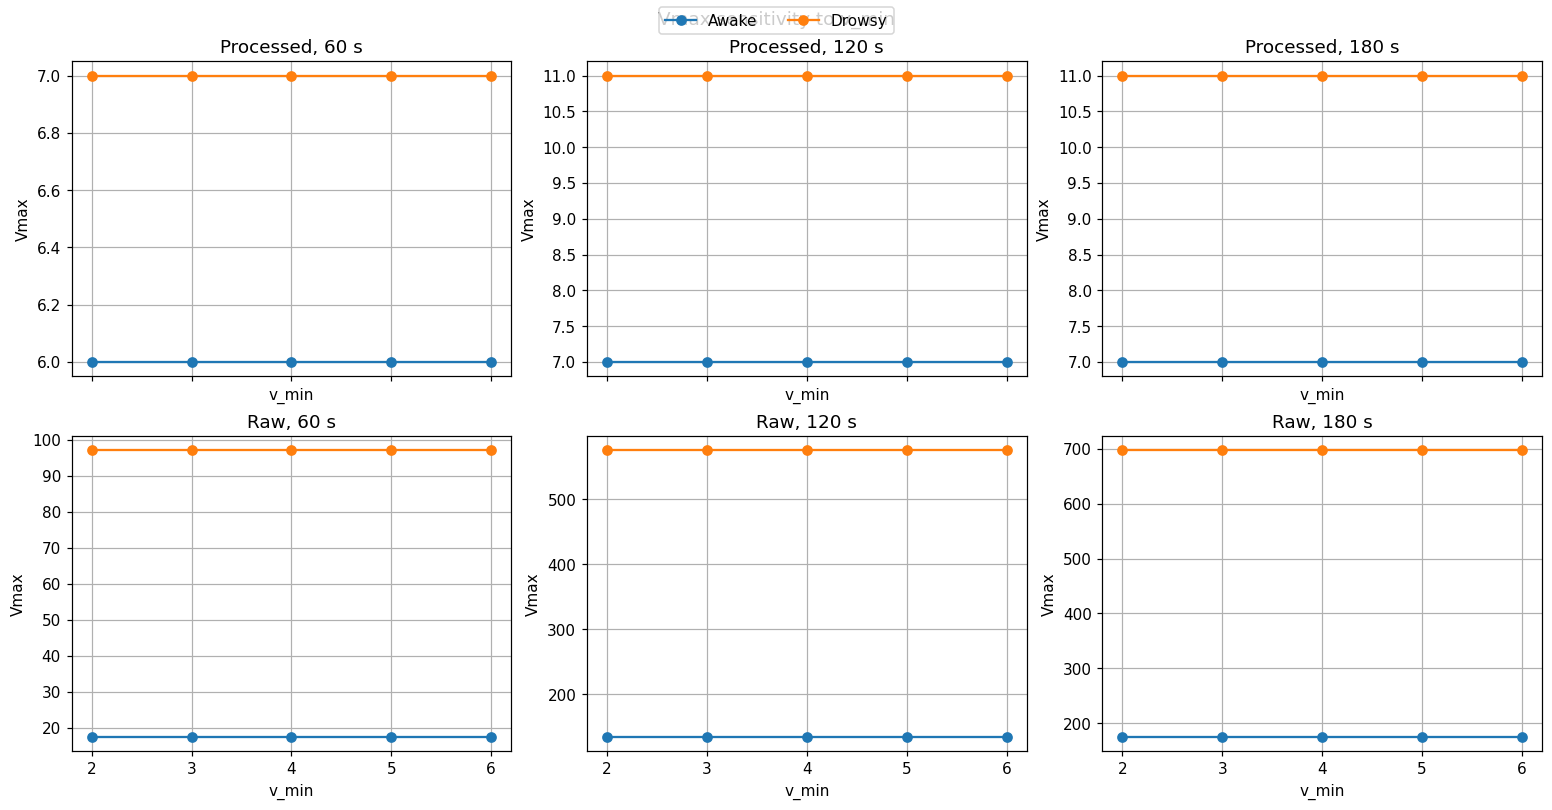

In [23]:
for vertical_metric in ("LAM", "TT", "Vmax"):
    plot_metric_grid(
        vertical_summary,
        cutoff="v_min",
        metric=vertical_metric,
        title=f"{vertical_metric} sensitivity to v_min",
    )


## Cell 24 — Vertical support versus v_min

Show qualifying line counts and retained vertical recurrence points for the support trade-off.


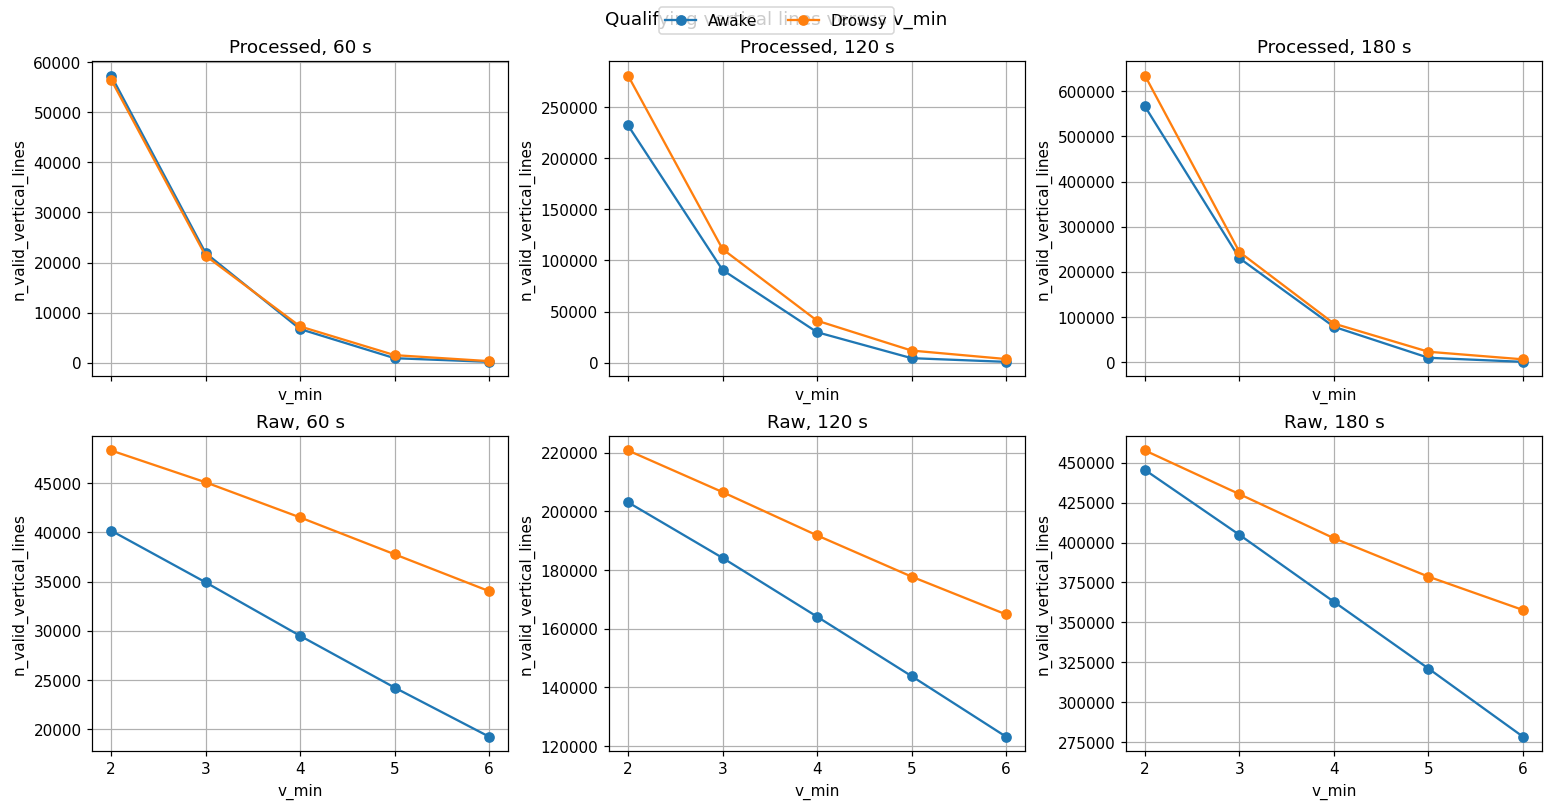

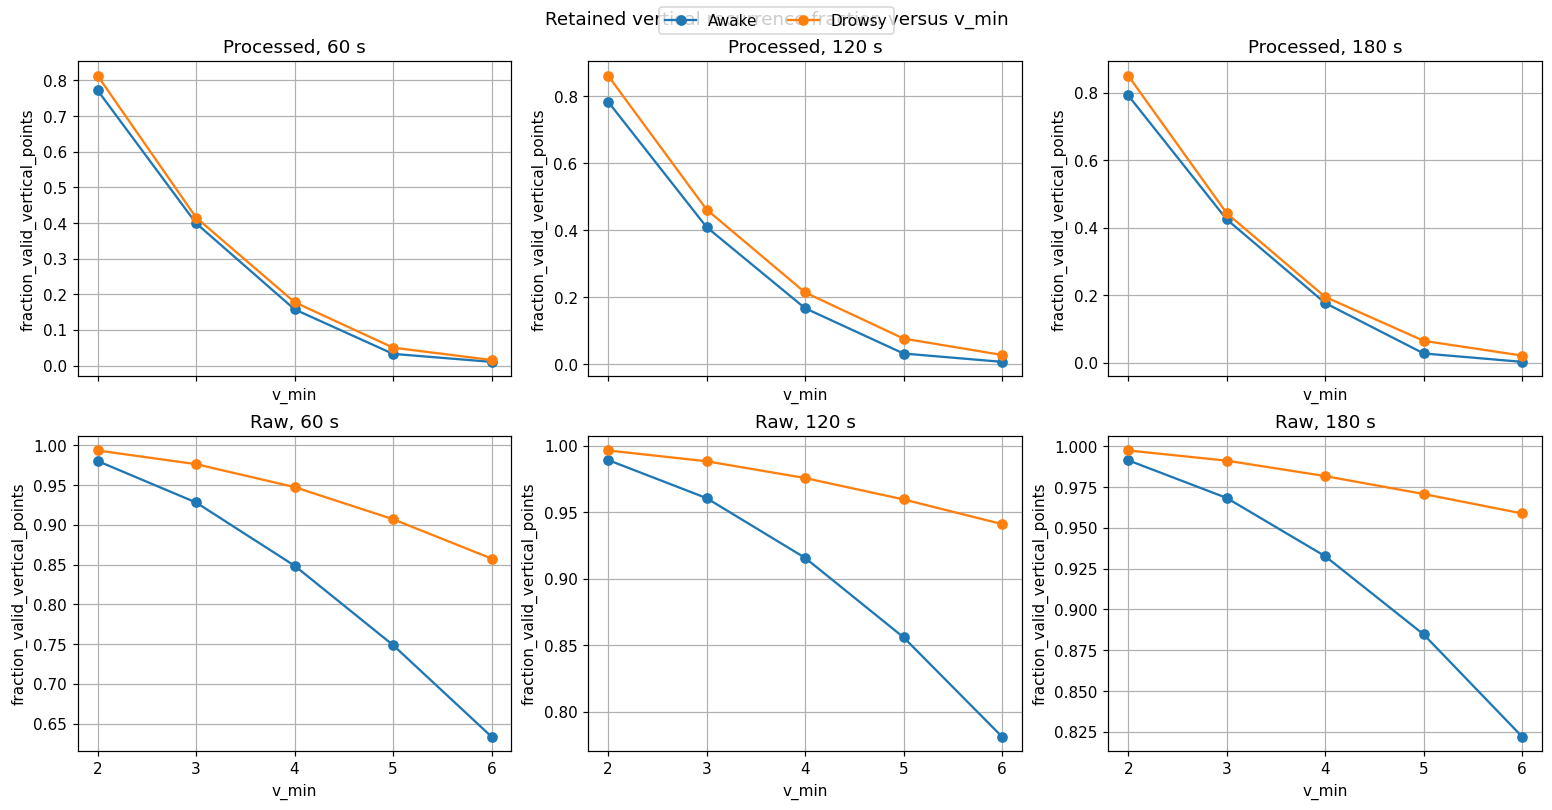

In [24]:
for support_metric, support_label in (
    ("n_valid_vertical_lines", "Qualifying vertical lines"),
    (
        "fraction_valid_vertical_points",
        "Retained vertical recurrence fraction",
    ),
):
    plot_metric_grid(
        vertical_summary.rename(
            columns={f"{support_metric}_mean": f"{support_metric}_median"}
        ),
        cutoff="v_min",
        metric=support_metric,
        title=f"{support_label} versus v_min",
    )


## Cell 25 — Numerical vertical sensitivity

Use `v_min = 2` as the within-window reference and report median relative changes with support retention.


In [25]:
vertical_relative_long = relative_changes(
    vertical_sensitivity_df,
    cutoff="v_min",
    metrics=["LAM", "TT", "Vmax"],
)
vertical_relative_table = (
    vertical_relative_long.groupby(["metric", "v_min"], observed=True)
    ["relative_change"]
    .median()
    .unstack("v_min")
)
vertical_support_table = (
    vertical_sensitivity_df.groupby("v_min", observed=True)
    .agg(
        median_point_retention=(
            "fraction_valid_vertical_points",
            "median",
        ),
        median_line_count=("n_valid_vertical_lines", "median"),
        zero_support_windows=(
            "n_valid_vertical_lines",
            lambda values: int((values == 0).sum()),
        ),
    )
)

display(vertical_relative_table)
display(vertical_support_table)


v_min,2,3,4,5,6
metric,,,,,
LAM,0.0,0.115679,0.279415,0.442079,0.611938
TT,0.0,0.141713,0.307216,0.489121,0.686909
Vmax,0.0,0.000000,0.000000,0.000000,0.000000


,median_point_retention,median_line_count,zero_support_windows
v_min,,,
2,0.959368,63589.0,0
3,0.848390,40098.0,0
4,0.686358,29454.0,0
5,0.531421,13109.0,0
6,0.369630,7048.0,11


## Cell 26 — Diagonal length distributions

Plot deterministic representative histograms. A missing 120-second cohort falls back to the nearest available duration.


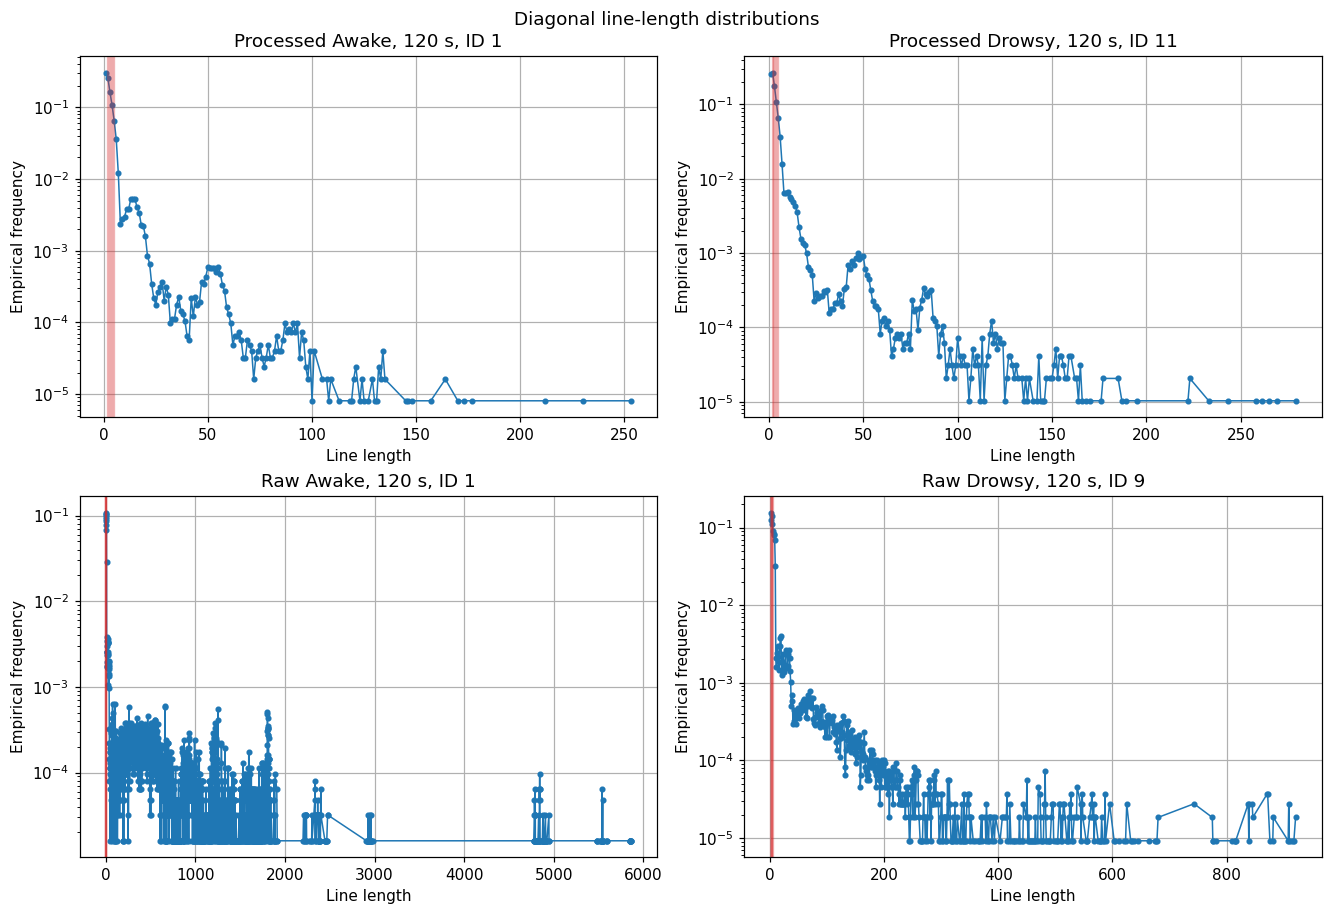

In [26]:
def select_representative_cache(representation, state, preferred_size=120):
    """Select a deterministic cached window without using RQA values."""
    candidates = [
        cache
        for cache in line_hist_cache.values()
        if cache["representation"] == representation
        and cache["state"] == state
    ]
    if not candidates:
        return None
    return min(
        candidates,
        key=lambda cache: (
            cache["window_size"] != preferred_size,
            abs(cache["window_size"] - preferred_size),
            cache["window_size"],
            cache["window_id"],
        ),
    )


def plot_length_distributions(value_key, count_key, cutoffs, title):
    """Plot empirical line-length frequencies for four fixed cohorts."""
    cohorts = [
        ("Processed", "Awake"),
        ("Processed", "Drowsy"),
        ("Raw", "Awake"),
        ("Raw", "Drowsy"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    for axis, (representation, state) in zip(axes.flat, cohorts):
        cache = select_representative_cache(representation, state)
        if cache is None:
            axis.text(
                0.5,
                0.5,
                "No eligible windows",
                ha="center",
                va="center",
                transform=axis.transAxes,
            )
            continue
        values = cache[value_key]
        counts = cache[count_key]
        frequencies = counts / counts.sum()
        axis.plot(values, frequencies, marker=".", linewidth=1.0)
        for cutoff in cutoffs:
            axis.axvline(cutoff, color="tab:red", alpha=0.35)
        axis.set_yscale("log")
        axis.set_title(
            f"{representation} {state}, "
            f"{cache['window_size']} s, ID {cache['window_id']}"
        )
        axis.set_xlabel("Line length")
        axis.set_ylabel("Empirical frequency")

    fig.suptitle(title, y=1.02)
    plt.show()


plot_length_distributions(
    "diagonal_values",
    "diagonal_counts",
    L_MIN_GRID,
    "Diagonal line-length distributions",
)


## Cell 27 — Vertical length distributions

Plot the corresponding empirical vertical-line distributions and mark all tested cutoffs.


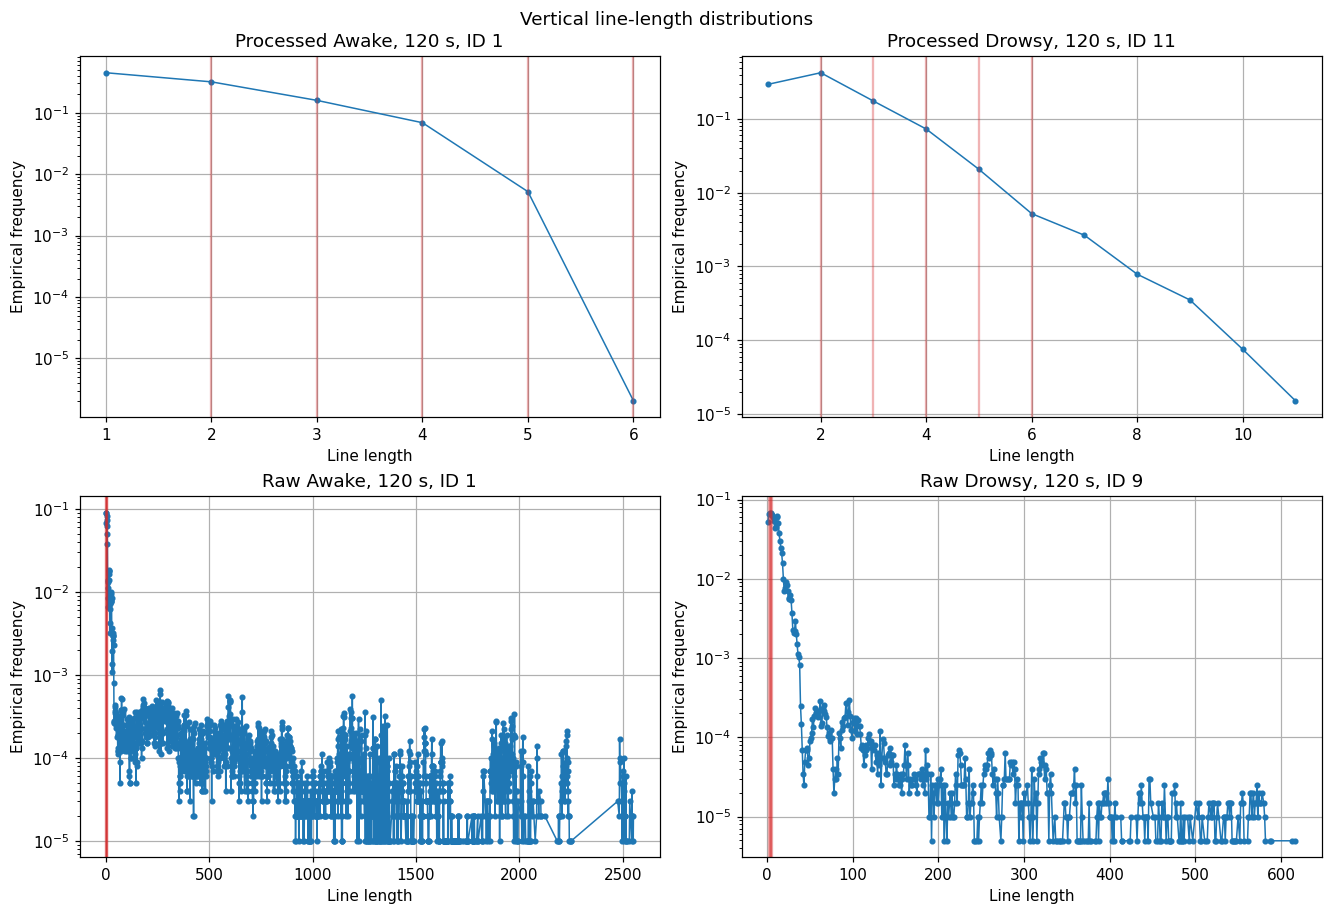

In [27]:
plot_length_distributions(
    "vertical_values",
    "vertical_counts",
    V_MIN_GRID,
    "Vertical line-length distributions",
)


## Cell 28 — Robustness by representation

Compare relative sensitivity for Raw and Processed PPG. These tables assess whether a common cutoff is plausible.


In [28]:
diagonal_representation_summary = (
    diagonal_relative_long.groupby(
        ["representation", "metric", "l_min"],
        observed=True,
    )["relative_change"]
    .median()
    .rename("median_relative_change")
    .reset_index()
)
vertical_representation_summary = (
    vertical_relative_long.groupby(
        ["representation", "metric", "v_min"],
        observed=True,
    )["relative_change"]
    .median()
    .rename("median_relative_change")
    .reset_index()
)

display(diagonal_representation_summary)
display(vertical_representation_summary)


,representation,metric,l_min,median_relative_change
0,Processed,DET,2,0.000000
1,Processed,DET,3,0.145090
2,Processed,DET,4,0.282234
3,Processed,DET,5,0.399428
4,Processed,ENTR,2,0.000000
5,Processed,ENTR,3,0.054044
6,Processed,ENTR,4,0.145870
7,Processed,ENTR,5,0.283479
8,Processed,Lmax,2,0.000000
9,Processed,Lmax,3,0.000000


,representation,metric,v_min,median_relative_change
0,Processed,LAM,2,0.000000
1,Processed,LAM,3,0.481242
2,Processed,LAM,4,0.786986
3,Processed,LAM,5,0.963884
4,Processed,LAM,6,0.998012
5,Processed,TT,2,0.000000
6,Processed,TT,3,0.333555
7,Processed,TT,4,0.641584
8,Processed,TT,5,1.015275
9,Processed,TT,6,1.365831


## Cell 29 — Robustness by window size

Compare cutoff sensitivity at 60, 120, and 180 seconds, with particular attention to entropy and maximum-line metrics.


In [29]:
diagonal_window_summary = (
    diagonal_relative_long.groupby(
        ["window_size", "metric", "l_min"],
        observed=True,
    )["relative_change"]
    .median()
    .rename("median_relative_change")
    .reset_index()
)
vertical_window_summary = (
    vertical_relative_long.groupby(
        ["window_size", "metric", "v_min"],
        observed=True,
    )["relative_change"]
    .median()
    .rename("median_relative_change")
    .reset_index()
)

display(diagonal_window_summary)
display(vertical_window_summary)


,window_size,metric,l_min,median_relative_change
0,60,DET,2,0.000000
1,60,DET,3,0.116363
2,60,DET,4,0.241679
3,60,DET,5,0.351657
4,60,ENTR,2,0.000000
5,60,ENTR,3,0.031294
6,60,ENTR,4,0.072442
7,60,ENTR,5,0.127091
8,60,Lmax,2,0.000000
9,60,Lmax,3,0.000000


,window_size,metric,v_min,median_relative_change
0,60,LAM,2,0.000000
1,60,LAM,3,0.118507
2,60,LAM,4,0.299228
3,60,LAM,5,0.495756
4,60,LAM,6,0.690317
5,60,TT,2,0.000000
6,60,TT,3,0.160480
7,60,TT,4,0.336144
8,60,TT,5,0.511020
9,60,TT,6,0.705367


## Cell 30 — Awake–Drowsy directional consistency

Inspect descriptive Drowsy-minus-Awake changes and sign flips. This diagnostic must not be used to optimize either cutoff.


In [30]:
def state_differences(data, cutoff, metrics):
    """Compute descriptive Drowsy-minus-Awake mean differences."""
    rows = []
    group_columns = ["representation", "window_size", cutoff]
    for metric in metrics:
        state_means = (
            data.groupby(group_columns + ["state"], observed=True)[metric]
            .mean()
            .unstack("state")
        )
        if not {"Awake", "Drowsy"}.issubset(state_means.columns):
            continue
        differences = (
            state_means["Drowsy"] - state_means["Awake"]
        ).rename("delta")
        metric_rows = differences.reset_index()
        metric_rows["metric"] = metric
        rows.append(metric_rows)
    return pd.concat(rows, ignore_index=True)


def summarize_sign_flips(data, cutoff):
    """Count directional sign changes across ordered cutoffs."""
    def count_flips(group):
        signs = np.sign(group.sort_values(cutoff)["delta"].to_numpy())
        signs = signs[signs != 0]
        if signs.size < 2:
            return 0
        return int(np.count_nonzero(signs[1:] != signs[:-1]))

    return (
        data.groupby(
            ["representation", "window_size", "metric"],
            observed=True,
        )
        .apply(count_flips, include_groups=False)
        .rename("n_sign_flips")
        .reset_index()
    )


diagonal_state_delta = state_differences(
    diagonal_sensitivity_df,
    "l_min",
    ["DET", "Lmean", "ENTR", "Lmax"],
)
vertical_state_delta = state_differences(
    vertical_sensitivity_df,
    "v_min",
    ["LAM", "TT", "Vmax"],
)

print("Descriptive only: do not select cutoffs from state separation.")
display(diagonal_state_delta)
display(summarize_sign_flips(diagonal_state_delta, "l_min"))
display(vertical_state_delta)
display(summarize_sign_flips(vertical_state_delta, "v_min"))


Descriptive only: do not select cutoffs from state separation.


,representation,window_size,l_min,delta,metric
0,Processed,60,2,0.010147,DET
1,Processed,60,3,0.016598,DET
2,Processed,60,4,0.020255,DET
3,Processed,60,5,0.026850,DET
4,Processed,120,2,0.019669,DET
...,...,...,...,...,...
91,Raw,120,5,62.363636,Lmax
92,Raw,180,2,466.500000,Lmax
93,Raw,180,3,466.500000,Lmax
94,Raw,180,4,466.500000,Lmax


,representation,window_size,metric,n_sign_flips
0,Processed,60,DET,0
1,Processed,60,ENTR,0
2,Processed,60,Lmax,0
3,Processed,60,Lmean,0
4,Processed,120,DET,0
5,Processed,120,ENTR,0
6,Processed,120,Lmax,0
7,Processed,120,Lmean,0
8,Processed,180,DET,0
9,Processed,180,ENTR,0


,representation,window_size,v_min,delta,metric
0,Processed,60,2,0.041237,LAM
1,Processed,60,3,0.015978,LAM
2,Processed,60,4,0.020055,LAM
3,Processed,60,5,0.017532,LAM
4,Processed,60,6,0.005163,LAM
...,...,...,...,...,...
85,Raw,180,2,-169.500000,Vmax
86,Raw,180,3,-169.500000,Vmax
87,Raw,180,4,-169.500000,Vmax
88,Raw,180,5,-169.500000,Vmax


,representation,window_size,metric,n_sign_flips
0,Processed,60,LAM,0
1,Processed,60,TT,0
2,Processed,60,Vmax,0
3,Processed,120,LAM,0
4,Processed,120,TT,0
5,Processed,120,Vmax,0
6,Processed,180,LAM,0
7,Processed,180,TT,0
8,Processed,180,Vmax,0
9,Raw,60,LAM,0


## Cell 31 — Automated sensitivity summary

Combine stability, support retention, and zero-support counts for each candidate. No candidate is labelled best.


In [31]:
def candidate_summary(
    relative_data,
    sensitivity_data,
    cutoff,
    retention_column,
    line_count_column,
):
    """Build a neutral cutoff assessment table."""
    stability = (
        relative_data.groupby(cutoff, observed=True)["relative_change"]
        .median()
        .rename("median_metric_relative_change")
    )
    support = sensitivity_data.groupby(cutoff, observed=True).agg(
        median_line_retention=(retention_column, "median"),
        median_qualifying_lines=(line_count_column, "median"),
        zero_support_windows=(
            line_count_column,
            lambda values: int((values == 0).sum()),
        ),
    )
    return support.join(stability).reset_index()


diagonal_candidate_summary = candidate_summary(
    diagonal_relative_long,
    diagonal_sensitivity_df,
    "l_min",
    "fraction_valid_diagonal_points",
    "n_valid_diagonal_lines",
)
vertical_candidate_summary = candidate_summary(
    vertical_relative_long,
    vertical_sensitivity_df,
    "v_min",
    "fraction_valid_vertical_points",
    "n_valid_vertical_lines",
)

display(diagonal_candidate_summary)
display(vertical_candidate_summary)


,l_min,median_line_retention,median_qualifying_lines,zero_support_windows,median_metric_relative_change
0,2,0.944457,21305.0,0,0.000000
1,3,0.836557,16703.0,0,0.055040
2,4,0.722011,12745.0,0,0.143752
3,5,0.615352,9637.0,0,0.254661


,v_min,median_line_retention,median_qualifying_lines,zero_support_windows,median_metric_relative_change
0,2,0.959368,63589.0,0,0.000000
1,3,0.848390,40098.0,0,0.055117
2,4,0.686358,29454.0,0,0.118548
3,5,0.531421,13109.0,0,0.204857
4,6,0.369630,7048.0,11,0.323961


## Cell 32 — Decision dashboard

Display the evidence needed for review. The notebook intentionally does not make the scientific cutoff decision.


In [32]:
print("Diagonal cutoff dashboard")
display(diagonal_candidate_summary)
display(diagonal_relative_table)
display(diagonal_representation_summary)
display(diagonal_window_summary)

print("Vertical cutoff dashboard")
display(vertical_candidate_summary)
display(vertical_relative_table)
display(vertical_representation_summary)
display(vertical_window_summary)

print("Decision:")
print("l_min = TO REVIEW")
print("v_min = TO REVIEW")
print()
print("If no clear plateau or support trade-off is present,")
print("extend the pilot to additional sessions.")


Diagonal cutoff dashboard


,l_min,median_line_retention,median_qualifying_lines,zero_support_windows,median_metric_relative_change
0,2,0.944457,21305.0,0,0.000000
1,3,0.836557,16703.0,0,0.055040
2,4,0.722011,12745.0,0,0.143752
3,5,0.615352,9637.0,0,0.254661


l_min,2,3,4,5
metric,,,,
DET,0.0,0.115470,0.234165,0.349285
ENTR,0.0,0.028361,0.071143,0.118444
Lmax,0.0,0.000000,0.000000,0.000000
Lmean,0.0,0.265279,0.548098,0.841493


,representation,metric,l_min,median_relative_change
0,Processed,DET,2,0.000000
1,Processed,DET,3,0.145090
2,Processed,DET,4,0.282234
3,Processed,DET,5,0.399428
4,Processed,ENTR,2,0.000000
5,Processed,ENTR,3,0.054044
6,Processed,ENTR,4,0.145870
7,Processed,ENTR,5,0.283479
8,Processed,Lmax,2,0.000000
9,Processed,Lmax,3,0.000000


,window_size,metric,l_min,median_relative_change
0,60,DET,2,0.000000
1,60,DET,3,0.116363
2,60,DET,4,0.241679
3,60,DET,5,0.351657
4,60,ENTR,2,0.000000
5,60,ENTR,3,0.031294
6,60,ENTR,4,0.072442
7,60,ENTR,5,0.127091
8,60,Lmax,2,0.000000
9,60,Lmax,3,0.000000


...

,v_min,median_line_retention,median_qualifying_lines,zero_support_windows,median_metric_relative_change
0,2,0.959368,63589.0,0,0.000000
1,3,0.848390,40098.0,0,0.055117
2,4,0.686358,29454.0,0,0.118548
3,5,0.531421,13109.0,0,0.204857
4,6,0.369630,7048.0,11,0.323961


v_min,2,3,4,5,6
metric,,,,,
LAM,0.0,0.115679,0.279415,0.442079,0.611938
TT,0.0,0.141713,0.307216,0.489121,0.686909
Vmax,0.0,0.000000,0.000000,0.000000,0.000000


,representation,metric,v_min,median_relative_change
0,Processed,LAM,2,0.000000
1,Processed,LAM,3,0.481242
2,Processed,LAM,4,0.786986
3,Processed,LAM,5,0.963884
4,Processed,LAM,6,0.998012
5,Processed,TT,2,0.000000
6,Processed,TT,3,0.333555
7,Processed,TT,4,0.641584
8,Processed,TT,5,1.015275
9,Processed,TT,6,1.365831


,window_size,metric,v_min,median_relative_change
0,60,LAM,2,0.000000
1,60,LAM,3,0.118507
2,60,LAM,4,0.299228
3,60,LAM,5,0.495756
4,60,LAM,6,0.690317
5,60,TT,2,0.000000
6,60,TT,3,0.160480
7,60,TT,4,0.336144
8,60,TT,5,0.511020
9,60,TT,6,0.705367


Decision:
l_min = TO REVIEW
v_min = TO REVIEW

If no clear plateau or support trade-off is present,
extend the pilot to additional sessions.


## Phase K — Recurrence-rate distribution diagnostics

Inspect recurrence density across representation, state, and window size. The five highest-RR windows are reported with signal-scale diagnostics, and the two densest recurrence plots are displayed.

,representation,state,window_size,n_windows,mean,median,std,minimum,q25,q75,q95,maximum
0,Processed,Awake,60,24,0.022519,0.024408,0.005211,0.012474,0.017919,0.026110,0.029149,0.032456
1,Processed,Awake,120,11,0.021777,0.022112,0.003892,0.014309,0.019214,0.024954,0.026250,0.026312
2,Processed,Awake,180,6,0.023167,0.023690,0.003437,0.016881,0.023293,0.024053,0.026597,0.027408
3,Processed,Drowsy,60,7,0.021099,0.020872,0.003856,0.015175,0.018893,0.023793,0.025827,0.026276
4,Processed,Drowsy,120,1,0.024507,0.024507,NaN,0.024507,0.024507,0.024507,0.024507,0.024507
5,Processed,Drowsy,180,1,0.024255,0.024255,NaN,0.024255,0.024255,0.024255,0.024255,0.024255
6,Raw,Awake,60,24,0.039329,0.028900,0.043916,0.013829,0.020992,0.041071,0.062592,0.235944
7,Raw,Awake,120,11,0.084394,0.048624,0.123937,0.021255,0.039948,0.065636,0.262634,0.454790
8,Raw,Awake,180,6,0.127483,0.060799,0.190497,0.023438,0.043525,0.065605,0.402756,0.514886
9,Raw,Drowsy,60,10,0.066614,0.056604,0.037101,0.021960,0.038309,0.085233,0.124921,0.140073


,representation,n_windows,median_rr,q95_rr,maximum_rr,n_rr_above_010,n_rr_above_020,n_rr_above_030,n_rr_above_040
0,Processed,50,0.023636,0.028274,0.032456,0,0,0,0
1,Raw,55,0.041703,0.168834,0.514886,8,3,2,2


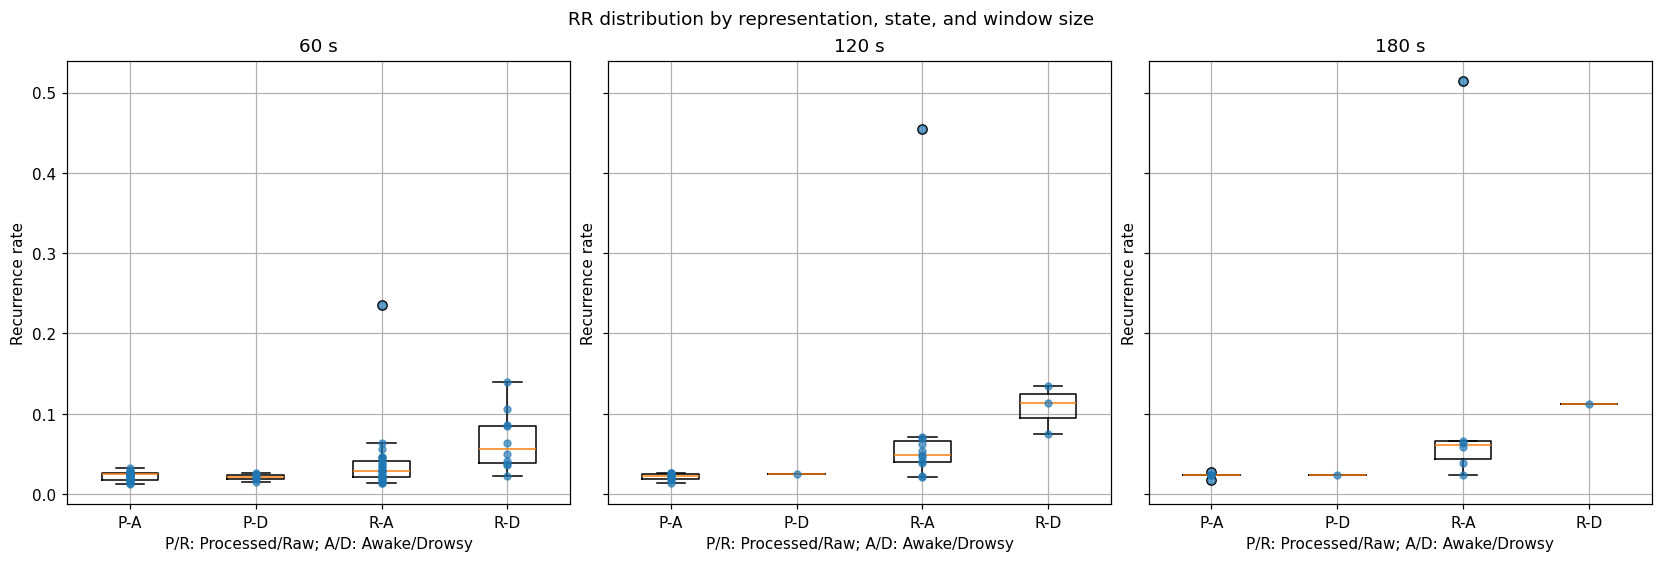

In [33]:
def q25(values):
    """Return the 25th percentile."""
    return values.quantile(0.25)


def q95(values):
    """Return the 95th percentile."""
    return values.quantile(0.95)


rr_distribution = (
    baseline_df.groupby(
        ["representation", "state", "window_size"],
        observed=True,
    )
    .agg(
        n_windows=("RR", "size"),
        mean=("RR", "mean"),
        median=("RR", "median"),
        std=("RR", "std"),
        minimum=("RR", "min"),
        q25=("RR", q25),
        q75=("RR", lambda values: values.quantile(0.75)),
        q95=("RR", q95),
        maximum=("RR", "max"),
    )
    .reset_index()
    .sort_values(["representation", "state", "window_size"])
)

rr_tail_counts = (
    baseline_df.assign(
        rr_above_010=baseline_df["RR"] > 0.10,
        rr_above_020=baseline_df["RR"] > 0.20,
        rr_above_030=baseline_df["RR"] > 0.30,
        rr_above_040=baseline_df["RR"] > 0.40,
    )
    .groupby("representation", observed=True)
    .agg(
        n_windows=("RR", "size"),
        median_rr=("RR", "median"),
        q95_rr=("RR", q95),
        maximum_rr=("RR", "max"),
        n_rr_above_010=("rr_above_010", "sum"),
        n_rr_above_020=("rr_above_020", "sum"),
        n_rr_above_030=("rr_above_030", "sum"),
        n_rr_above_040=("rr_above_040", "sum"),
    )
    .reset_index()
)

display(rr_distribution)
display(rr_tail_counts)

fig, axes = plt.subplots(
    1,
    len(WINDOW_SIZES),
    figsize=(15, 5),
    sharey=True,
    constrained_layout=True,
)
cohorts = [
    ("Processed", "Awake"),
    ("Processed", "Drowsy"),
    ("Raw", "Awake"),
    ("Raw", "Drowsy"),
]
labels = ["P-A", "P-D", "R-A", "R-D"]

for axis, window_size in zip(axes, WINDOW_SIZES):
    distributions = [
        baseline_df.loc[
            (baseline_df["representation"] == representation)
            & (baseline_df["state"] == state)
            & (baseline_df["window_size"] == window_size),
            "RR",
        ].to_numpy()
        for representation, state in cohorts
    ]
    axis.boxplot(
        distributions,
        tick_labels=labels,
        showfliers=True,
    )
    for position, values in enumerate(distributions, start=1):
        axis.scatter(
            np.full(values.size, position),
            values,
            color="tab:blue",
            alpha=0.65,
            s=20,
            zorder=3,
        )
    axis.set_title(f"{window_size} s")
    axis.set_xlabel("P/R: Processed/Raw; A/D: Awake/Drowsy")
    axis.set_ylabel("Recurrence rate")

fig.suptitle("RR distribution by representation, state, and window size")
plt.show()

In [34]:
window_lookup = {
    (
        item["representation"],
        item["state"],
        item["window_size"],
        item["window_id"],
    ): item
    for item in selected_windows
}

top_rr_windows = baseline_df.nlargest(5, "RR").copy()
top_rr_windows["Dmax"] = (
    top_rr_windows["epsilon"] / RADIUS_FRACTION
)

signal_ranges = []
signal_standard_deviations = []
for row in top_rr_windows.itertuples(index=False):
    key = (
        row.representation,
        row.state,
        row.window_size,
        row.window_id,
    )
    signal = np.asarray(window_lookup[key]["signal"], dtype=float)
    signal_ranges.append(float(np.ptp(signal)))
    signal_standard_deviations.append(float(np.std(signal, ddof=1)))

top_rr_windows["signal_range"] = signal_ranges
top_rr_windows["signal_sd"] = signal_standard_deviations
top_rr_report = top_rr_windows[
    [
        "RR",
        "Dmax",
        "epsilon",
        "representation",
        "state",
        "window_size",
        "window_id",
        "signal_range",
        "signal_sd",
    ]
].reset_index(drop=True)
top_rr_report.index = np.arange(1, len(top_rr_report) + 1)
top_rr_report.index.name = "rank"

display(top_rr_report)

,RR,Dmax,epsilon,representation,state,window_size,window_id,signal_range,signal_sd
rank,,,,,,,,,
1,0.514886,22226.450166,2222.645017,Raw,Awake,180,1,8312.0,1504.998928
2,0.454790,20672.138569,2067.213857,Raw,Awake,120,1,7755.0,1637.210175
3,0.235944,19406.882619,1940.688262,Raw,Awake,60,1,7345.0,1872.077694
4,0.140073,4031.563716,403.156372,Raw,Drowsy,60,31,1582.0,345.242151
5,0.134549,4100.301330,410.030133,Raw,Drowsy,120,14,1640.0,306.488768


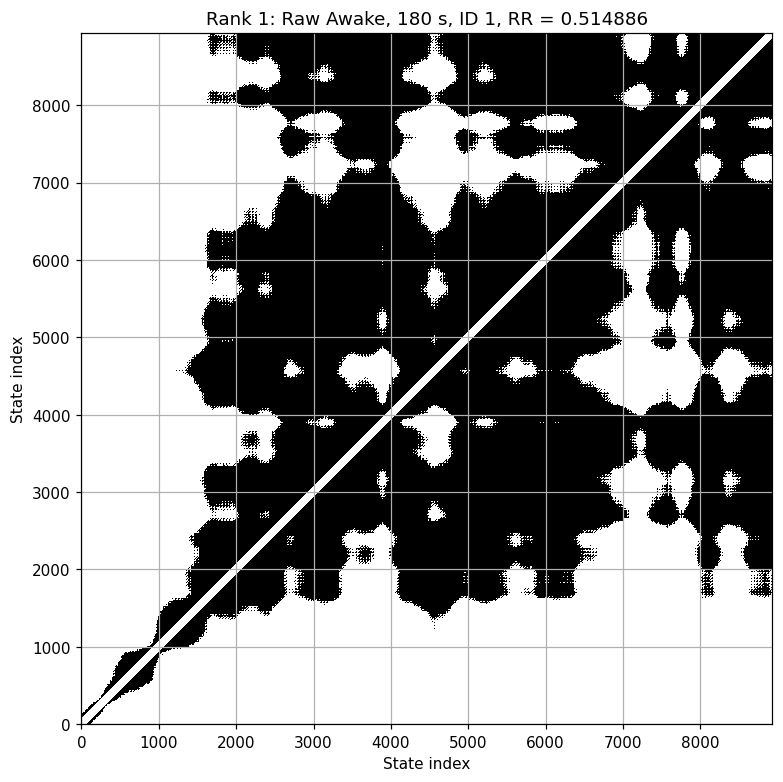

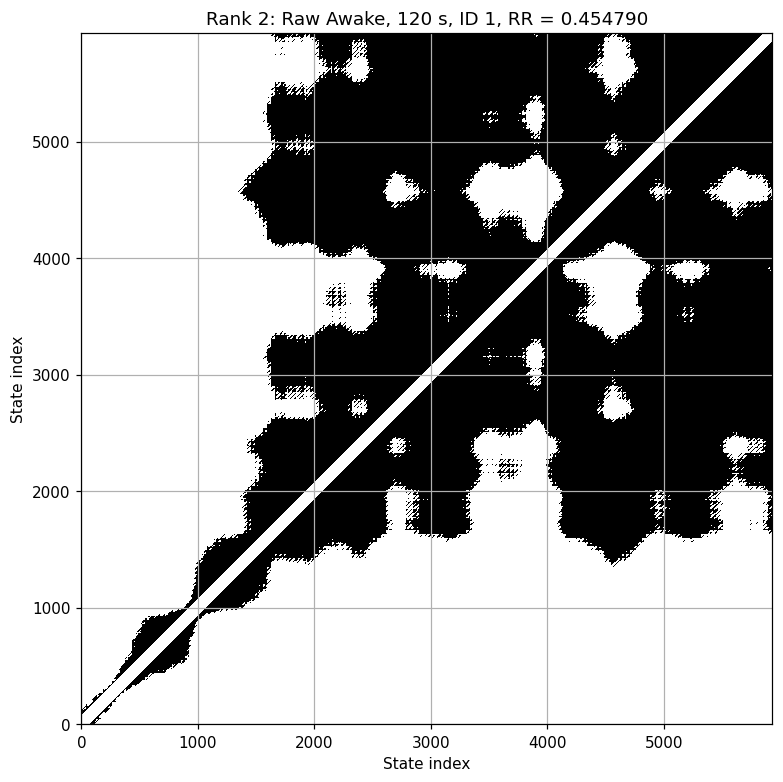

In [35]:
for rank, row in top_rr_report.head(2).iterrows():
    key = (
        row["representation"],
        row["state"],
        int(row["window_size"]),
        int(row["window_id"]),
    )
    item = window_lookup[key]
    tau = int(
        round(TAU_SECONDS[row["representation"]] * item["fs"])
    )
    theiler = (M - 1) * tau
    states = rqa_core.reconstruct_phase_space(
        item["signal"],
        m=M,
        tau=tau,
    )
    distances = rqa_core.compute_distance_matrix(states)
    recurrence, _ = rqa_core.compute_recurrence_matrix(
        distances,
        radius_fraction=RADIUS_FRACTION,
    )
    recurrence = rqa_core.apply_theiler_window(
        recurrence,
        theiler=theiler,
    )

    fig, axis = plt.subplots(figsize=(7, 7), constrained_layout=True)
    axis.imshow(
        recurrence,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="binary",
    )
    axis.set_title(
        f"Rank {rank}: {row['representation']} {row['state']}, "
        f"{int(row['window_size'])} s, ID {int(row['window_id'])}, "
        f"RR = {row['RR']:.6f}"
    )
    axis.set_xlabel("State index")
    axis.set_ylabel("State index")
    plt.show()

    del states, distances, recurrence
    gc.collect()

# Tổng hợp kết quả RQA

## 1. Kết quả kiểm tra core RQA

### 1.1. Kết quả các kiểm tra

| Kiểm tra | Kết quả |
|---|---|
| Synthetic periodic signal | PASS |
| Synthetic Gaussian noise | PASS |
| Recurrence-plot symmetry | PASS |
| Theiler corridor exclusion | PASS |
| Line-of-identity exclusion | PASS |
| Diagonal-line extraction | PASS |
| Vertical-line extraction | PASS |
| DET formula | PASS |
| Lmean formula | PASS |
| ENTR formula | PASS |
| Lmax formula | PASS |
| LAM formula | PASS |
| TT formula | PASS |
| Vmax formula | PASS |

### 1.2. Kết quả trên tín hiệu synthetic

| Metric | Periodic | Noise |
|---|---:|---:|
| DET | 0.999473 | 0.000000 |
| Lmean | 75.800000 | 0.000000 |
| ENTR | 1.453815 | 0.000000 |
| Lmax | 861 | 0 |
| LAM | 0.999077 | 0.000000 |
| TT | 2.845287 | 0.000000 |
| Vmax | 3 | 0 |
| RR | 0.067400 | 0.000086 |
| Epsilon | 0.405923 | 0.933256 |
| Theiler | 56 | 56 |
| Số diagonal lines | 350 | 0 |
| Số vertical lines | 18641 | 0 |

### 1.3. Kết quả trên representative real window

| Thuộc tính | Giá trị |
|---|---:|
| Representation | Processed |
| State | Awake |
| Window size | 120 s |
| Window ID | 1 |
| Signal samples | 6000 |
| Embedded vectors | 5944 |
| tau_samples | 8 |
| theiler_samples | 56 |
| Dmax | 1293.23 |
| Epsilon | 129.323 |
| RR | 0.026312 |
| Số diagonal lines | 86056 |
| Số vertical lines | 269934 |
| DET | 0.917836 |
| Lmean | 4.863786 |
| ENTR | 1.943784 |
| Lmax | 253 |
| LAM | 0.759484 |
| TT | 2.566146 |
| Vmax | 6 |

### 1.4. Session 1 baseline QC

Processed dùng Processed stationarity. Raw dùng toàn bộ cửa sổ qua SQI và
không lọc stationarity.

| Chỉ tiêu | Giá trị |
|---|---:|
| Windows tested | 105 |
| Invalid outputs | 0 |
| Zero diagonal support | 0 |
| Zero vertical support | 0 |
| Pathological RR | 0 |
| RR minimum | 0.012474 |
| RR maximum | 0.514886 |

## 2. Kết quả sensitivity của l_min và v_min

### 2.1. Sensitivity của l_min

Median relative change so với `l_min = 2`:

| Metric | l_min = 2 | l_min = 3 | l_min = 4 | l_min = 5 |
|---|---:|---:|---:|---:|
| DET | 0.000000 | 0.115470 | 0.234165 | 0.349285 |
| ENTR | 0.000000 | 0.028361 | 0.071143 | 0.118444 |
| Lmax | 0.000000 | 0.000000 | 0.000000 | 0.000000 |
| Lmean | 0.000000 | 0.265279 | 0.548098 | 0.841493 |

Line support và median metric relative change:

| l_min | Median line retention | Median qualifying lines | Zero-support windows | Median metric relative change |
|---:|---:|---:|---:|---:|
| 2 | 0.944457 | 21305 | 0 | 0.000000 |
| 3 | 0.836557 | 16703 | 0 | 0.055040 |
| 4 | 0.722011 | 12745 | 0 | 0.143752 |
| 5 | 0.615352 | 9637 | 0 | 0.254661 |

### 2.2. Sensitivity của v_min

Median relative change so với `v_min = 2`:

| Metric | v_min = 2 | v_min = 3 | v_min = 4 | v_min = 5 | v_min = 6 |
|---|---:|---:|---:|---:|---:|
| LAM | 0.000000 | 0.115679 | 0.279415 | 0.442079 | 0.611938 |
| TT | 0.000000 | 0.141713 | 0.307216 | 0.489121 | 0.686909 |
| Vmax | 0.000000 | 0.000000 | 0.000000 | 0.000000 | 0.000000 |

Line support và median metric relative change:

| v_min | Median line retention | Median qualifying lines | Zero-support windows | Median metric relative change |
|---:|---:|---:|---:|---:|
| 2 | 0.959368 | 63589 | 0 | 0.000000 |
| 3 | 0.848390 | 40098 | 0 | 0.055117 |
| 4 | 0.686358 | 29454 | 0 | 0.118548 |
| 5 | 0.531421 | 13109 | 0 | 0.204857 |
| 6 | 0.369630 | 7048 | 11 | 0.323961 |

## 3. Kết quả phân phối recurrence rate

### 3.1. Tổng hợp theo representation

| Representation | Số windows | Median RR | RR q95 | RR maximum | RR > 0.10 | RR > 0.20 | RR > 0.30 | RR > 0.40 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Processed | 50 | 0.023636 | 0.028274 | 0.032456 | 0 | 0 | 0 | 0 |
| Raw | 55 | 0.041703 | 0.168834 | 0.514886 | 8 | 3 | 2 | 2 |

### 3.2. Năm windows có RR cao nhất

| Rank | RR | Dmax | Epsilon | Representation | State | Window size | Window ID | Signal range | Signal SD |
|---:|---:|---:|---:|---|---|---:|---:|---:|---:|
| 1 | 0.514886 | 22226.450166 | 2222.645017 | Raw | Awake | 180 | 1 | 8312 | 1504.998928 |
| 2 | 0.454790 | 20672.138569 | 2067.213857 | Raw | Awake | 120 | 1 | 7755 | 1637.210175 |
| 3 | 0.235944 | 19406.882619 | 1940.688262 | Raw | Awake | 60 | 1 | 7345 | 1872.077694 |
| 4 | 0.140073 | 4031.563716 | 403.156372 | Raw | Drowsy | 60 | 31 | 1582 | 345.242151 |
| 5 | 0.134549 | 4100.301330 | 410.030133 | Raw | Drowsy | 120 | 14 | 1640 | 306.488768 |

Ba windows đứng đầu có cùng `window_id = 1`, cùng thời điểm bắt đầu
`2.63 s`, và thời điểm kết thúc lần lượt là `62.61 s`, `122.61 s`,
`182.61 s`.